In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "data/OMXS22_raw_features.csv",
    parse_dates=["Date"],
    index_col="Date"
)
start_test_point = df.index[-510*22]
print(start_test_point)
all_tickers = df['Ticker'].unique()
print(all_tickers)


feature_cols = ["Close","Volume",
                "MarketCap","Weight",
                "Return","LogReturn","WeightedRet",
                "SMA20","EMA20","RSI14","ReturnVola20"]

chosen_ticker = "KINV-B.ST"

import numpy, torch, scipy
print("NumPy :", numpy.__version__)   # → 1.26.4
print("Torch :", torch.__version__)   # → 2.2.2
print("SciPy :", scipy.__version__)   # → 1.15.2

2023-04-17 00:00:00
['ASSA-B.ST' 'ATCO-A.ST' 'ATCO-B.ST' 'AZN.ST' 'ELUX-B.ST' 'ERIC-B.ST'
 'GETI-B.ST' 'HEXA-B.ST' 'HM-B.ST' 'INVE-B.ST' 'KINV-B.ST' 'NDA-SE.ST'
 'NIBE-B.ST' 'SAAB-B.ST' 'SAND.ST' 'SCA-B.ST' 'SEB-A.ST' 'SHB-A.ST'
 'SKF-B.ST' 'SWED-A.ST' 'TEL2-B.ST' 'VOLV-B.ST']
NumPy : 2.2.4
Torch : 2.5.1
SciPy : 1.15.2


In [2]:

window_step_length = 5
window_size = 40
num_test_points = 511

horizon = 20 #3 is good
target_idx = 0



In [3]:
import matplotlib.pyplot as plt
import numpy as np
import deeptrack as dt
import torch
from torch.utils.data import DataLoader
def generate_loaders_and_benchmark_new_norm(raw_numpy_data, window_step_length, num_test_points, window_size, horizon, target_idx, minimal_plotting=False):

    data = raw_numpy_data[:-num_test_points]
    test_real_data = raw_numpy_data[-num_test_points:]
    #print(data[-1])
    #print(test_real_data[0])
    if not minimal_plotting:
        plt.plot(test_real_data[:,0])
        plt.title('Test data plot')
        plt.show()

    n_samples = data.shape[0]
    past_seq = window_size
    lag = horizon

    in_sequences, targets = [], []
    for i in range(past_seq, n_samples - lag, window_step_length):
        in_sequences.append(data[i - past_seq:i, :])
        targets.append(data[i + lag:i + lag + 1, target_idx])
    in_sequences, targets = np.asarray(in_sequences), np.asarray(targets)
    #print(in_sequences[10][horizon,target_idx])
    #print(targets[9])

    print('in sequences shape: ',in_sequences.shape)
    print('targets shape: ',targets.shape)
    eps = 0
    mean_win = in_sequences.mean(axis=0, keepdims=True)
    std_win = in_sequences.std(axis=0, keepdims=True) + eps

    print(in_sequences[0,0])
    print(mean_win[0,0])
    print(std_win[0,0])
    in_sequences_norm = (in_sequences - mean_win) / std_win
    print(in_sequences_norm[0,0])
    target_mean = mean_win[:,0,target_idx]
    target_std = std_win[:,0,target_idx]
    targets_norm = ((targets.squeeze(-1) - target_mean) / target_std)
    targets_norm = targets_norm.reshape(-1,1)
    print('in sequences norm shape: ',in_sequences_norm.shape)
    print('targets norm shape: ',targets_norm.shape)

    sources = dt.sources.Source(inputs=in_sequences_norm, targets=targets_norm)
    train_sources, val_sources = dt.sources.random_split(sources, [0.8, 0.2])

    inputs_pipeline = dt.Value(sources.inputs) >> dt.pytorch.ToTensor(dtype=torch.float)
    targets_pipeline = dt.Value(sources.targets) >> dt.pytorch.ToTensor(dtype=torch.float) 

    train_dataset = dt.pytorch.Dataset(inputs_pipeline & targets_pipeline,
                                       inputs=train_sources)
    val_dataset = dt.pytorch.Dataset(inputs_pipeline & targets_pipeline,
                                     inputs=val_sources)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    print('train loader length: ', len(train_loader))
    print('val loader length: ', len(val_loader))
    #for x, y in train_loader:
    #    print(y[0])
    #    print(x[0])
    target_data = data[:, target_idx]
    indices = np.arange(0, len(target_data)-lag)
    diffs = np.abs(target_data[indices + lag] - target_data[indices])
    benchmark_raw = np.mean(diffs)
    benchmark = 0.1 #benchmark_raw / train_std[target_idx]


    print(f"Benchmark Celsius: {benchmark_raw}")
    print(f"Normalized Benchmark: {benchmark}")

    return train_loader, val_loader, benchmark, mean_win, std_win

In [4]:
def generate_weights_from_predictions_new_norm(model, window_size, real_data, target_idx, num_of_future_predictions, horizon, kelly_clip = 1, print_values_for_allocation=False):
    model.eval()

    # 1) Compute in‐sample return variance (on training history)
    #    use price in column 0
    prices = real_data[:-num_of_future_predictions, 0]
    ret = (prices[horizon:] - prices[:-horizon]) / prices[:-horizon]
    sigma2 = np.var(ret)
    print('variance of returns for old data: ', sigma2)


    last_window = torch.tensor(real_data[-window_size-num_of_future_predictions:-num_of_future_predictions], dtype=torch.float32)
    
    print('start window shape: ',last_window.shape)
    #print(last_window)

    test_real_data_torch = torch.tensor(real_data[-num_of_future_predictions:], dtype=torch.float32)

    #train_mean = real_data.mean(axis=0)
    #train_std = real_data.std(axis=0)
    #train_mean_torch = torch.tensor(train_mean, dtype=torch.float32)
    #train_std_torch = torch.tensor(train_std, dtype=torch.float32)
    #print(train_mean_torch)
    #print(train_std_torch)

    #test_real_data_torch_norm = (test_real_data_torch - train_mean_torch)/ train_std_torch
    print('test data shape', test_real_data_torch.shape)

    #print(test_real_data_torch)

    preds_norm = np.zeros(num_of_future_predictions)
    weights = np.zeros(int(num_of_future_predictions/horizon))
    

    with torch.no_grad():
        for t in range(int(num_of_future_predictions/horizon)-1):

            idx_start = t * horizon
            idx_end = idx_start + horizon
            lw_mean = last_window.mean(axis=0, keepdim=True)
            lw_std = last_window.std(axis=0, keepdim=True)
            #lw_mean_t = torch.tensor(lw_mean)
            #lw_std_t = torch.tensor(lw_std)
            print('lw mean', lw_mean)

            last_window_norm = (last_window - lw_mean ) / lw_std

            x_in  = last_window_norm.unsqueeze(0)
            pred_torch = model(x_in)
            #print('pred:', pred_torch)
            pred_norm = pred_torch.squeeze().item()

            preds_norm[idx_start] = pred_norm
            #print('real: ', test_real_data_torch[t, 0])

            last_price_real = test_real_data_torch[idx_start, 0] if t>0 else real_data[-num_of_future_predictions-1, 0]
            #print(last_price_real)
            pred_price = pred_norm * lw_std[0,target_idx] + lw_mean[0,target_idx]
            pred_ret = (pred_price - last_price_real)/last_price_real
            print('ret shape', pred_ret.shape)

            #kelly weight
            k = pred_ret / np.sqrt(sigma2) if sigma2 > 1e-8 else 0.0
            k = np.clip(k, -kelly_clip, kelly_clip)
            #print(k.shape)

            weights[t] = k
            
            true_horizon_price = test_real_data_torch[idx_end, 0]
            if print_values_for_allocation:
                print('x_in shape: ', x_in.shape)
                print('windows last price: ',x_in[0,-1,0] * lw_std[0,target_idx] + lw_mean[0,target_idx])
                print('windows last2 price: ',x_in[0,-2,0] * lw_std[0,target_idx] + lw_mean[0,target_idx])
                print('windows last3 price: ',x_in[0,-3,0] * lw_std[0,target_idx] + lw_mean[0,target_idx])

                print(f'period from idx: ', idx_start, ' to idx ', idx_end)
                
                print(f'prediction at {horizon}: ', pred_price)
                print('last price from test data: ', last_price_real)
                print(f'real price {horizon} steps forward: ', true_horizon_price)
                print(f'kelly weight: ', {k})
                print(' ')
            
            

            true_row = test_real_data_torch[idx_end, :]# if t>0 else real_data[-num_of_future_predictions-1, 0]
            #true_indicators[0] = pred_norm

            next_data_point = torch.tensor(true_row, dtype=torch.float32)
            if horizon > 1:
                middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)
                #print(middle_points.shape)
                #print(next_data_point.unsqueeze(0).shape)
                #print('last window in: ',last_window.shape)
                modified_next_data_point = torch.cat([middle_points, next_data_point.unsqueeze(0)], dim=0)
            else:
                modified_next_data_point = next_data_point.unsqueeze(0)
            #print('mod shape', modified_next_data_point.shape)
            last_window = torch.cat([last_window[horizon:], modified_next_data_point], dim=0)
            #print('last window shape: ', last_window.shape)

    return preds_norm, weights

In [5]:
def generate_test_data_loader(data):
    in_seqs, targets, mu_list, sigma_list = [], [], [], []
    n_samples = data.shape[0]
    past_seq = window_size
    lag = horizon

    for i in range(past_seq, n_samples - lag, window_step_length):
        win   = data[i - past_seq : i, :]           # (past_seq, F)
        μ     = win.mean(axis=0)                    # (F,)
        σ     = win.std(axis=0) + 1e-8              # (F,)
    
        in_seqs.append((win - μ) / σ)               # normalised
        targets.append(data[i + lag, target_idx])   # scalar
        mu_list.append(μ[target_idx])
        sigma_list.append(σ[target_idx])
    
    in_seqs = np.asarray(in_seqs)                   # (N, past_seq, F)
    targets = np.asarray(targets).reshape(-1, 1)    # (N, 1)
    mu_arr  = np.asarray(mu_list).reshape(-1, 1)    # (N, 1)
    sigma_arr = np.asarray(sigma_list).reshape(-1, 1)
    
    targets_norm = (targets - mu_arr) / sigma_arr   # (N, 1)
    
    # ------------------------------------------------------------------
    # Build dt Source with μ and σ columns
    # ------------------------------------------------------------------
    test_sources = dt.sources.Source(
        inputs=in_seqs,
        targets=targets_norm,
        mu=mu_arr,
        sigma=sigma_arr,
    )
    
    
    # ------------------------------------------------------------------
    # Pipelines  →  tensors
    # ------------------------------------------------------------------
    to_tensor = dt.pytorch.ToTensor(dtype=torch.float)
    
    inp_pipe  = dt.Value(test_sources.inputs) >> to_tensor
    tgt_pipe  = dt.Value(test_sources.targets) >> to_tensor
    mu_pipe   = dt.Value(test_sources.mu)      >> to_tensor
    sigma_pipe= dt.Value(test_sources.sigma)   >> to_tensor
    
    dataset_cols = inp_pipe & tgt_pipe & mu_pipe & sigma_pipe
    
    test_ds = dt.pytorch.Dataset(dataset_cols, inputs=test_sources)
    
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

    return test_loader
   

In [6]:
def test_model_output_percentage_diff_new_norm(model, data_loader, tm, tstd, target_idx, num_tests=20):
    
    model.eval()

    all_preds_real, all_true_real = [], []
    first_batch = None   # keep for pretty print

    with torch.no_grad():
        for x_batch, y_norm, mu_batch, sigma_batch in data_loader:
            # to(device) only if you trained on GPU
            #x_batch     = x_batch.to(device)
            #y_norm      = y_norm.to(device)
            #mu_batch    = mu_batch.to(device)
            #sigma_batch = sigma_batch.to(device)

            # forward
            out = model(x_batch)
            if isinstance(out, (tuple, list)):   # ignore extra returns
                out = out[0]
            out = out.squeeze(-1)                # (B,)

            # ------------------------------------------
            # de-normalise: y_real = y_norm * σ + μ
            # ------------------------------------------
            preds_real = out * sigma_batch.squeeze(-1) + mu_batch.squeeze(-1)
            true_real  = y_norm.squeeze(-1) * sigma_batch.squeeze(-1) + mu_batch.squeeze(-1)

            all_preds_real.append(preds_real)
            all_true_real.append(true_real)

            if first_batch is None:
                first_batch = (
                    x_batch.cpu(),      # still normalised
                    y_norm.cpu(),
                    mu_batch.cpu(),
                    sigma_batch.cpu(),
                    out.cpu(),          # preds in norm space
                )

    # ------------------------------------------------------------------
    # 1. MAPE over the whole loader   (real price space)
    # ------------------------------------------------------------------
    preds = torch.cat(all_preds_real)            # (N,)
    truth = torch.cat(all_true_real)             # (N,)

    mape = ((preds - truth).abs() / truth.abs().clamp(min=1e-8) * 100).mean().item()
    print(f"\nMean absolute percentage error (MAPE): {mape:.2f}%")

    # ------------------------------------------------------------------
    # 2. Pretty-print a few samples from the first batch
    # ------------------------------------------------------------------
    x_b, y_norm_b, mu_b, sigma_b, p_norm_b = first_batch
    num_tests = min(num_tests, x_b.size(0))

    print(f"\nFirst-batch sample comparisons (n = {num_tests}):")
    for i in range(num_tests):
        # last raw price of target feature in the window
        last_price = (
            x_b[i, -1, target_idx].item() * sigma_b[i].item() + mu_b[i].item()
        )

        true_price = y_norm_b[i].item() * sigma_b[i].item() + mu_b[i].item()
        pred_price = p_norm_b[i].item()  * sigma_b[i].item() + mu_b[i].item()
        pct = abs(pred_price - true_price) / abs(true_price) * 100

        print(
            f"  Sample {i+1:2d}: "
            f"Last input price = {last_price:9.4f}, "
            f"True = {true_price:9.4f}, "
            f"Pred = {pred_price:9.4f}, "
            f"Pct diff = {pct:6.2f}%"
        )

    return mape

Shape dataset (6409, 11)
means:  Close           1.043935e+02
Volume          4.174720e+06
MarketCap       1.099524e+11
Weight          3.379463e-02
Return          5.710548e-04
LogReturn       3.715475e-04
WeightedRet     2.191627e-05
SMA20           1.040219e+02
EMA20           1.040130e+02
RSI14           5.227815e+01
ReturnVola20    1.814528e-02
dtype: float64
stds:  Close           8.875950e+01
Volume          4.600011e+06
MarketCap       9.348594e+10
Weight          1.282733e-02
Return          2.000137e-02
LogReturn       1.996333e-02
WeightedRet     6.095575e-04
SMA20           8.849015e+01
EMA20           8.844715e+01
RSI14           1.056618e+01
ReturnVola20    8.856161e-03
dtype: float64


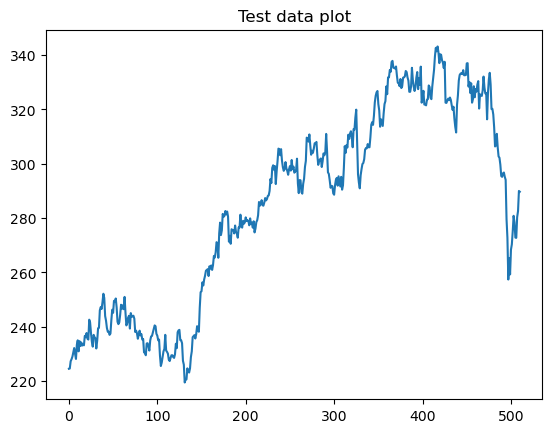

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[2.68834782e+01 1.57131000e+05 2.83150229e+10 1.55002267e-02
 3.92147114e-03 3.91380222e-03 6.07836916e-05 2.63111549e+01
 2.67990432e+01 5.31894275e+01 2.79775678e-02]
[ 8.72255660e+01  4.16747079e+06  9.18703260e+10  3.28666582e-02
  1.91744196e-05 -1.87802332e-04  1.37194232e-05  8.69093176e+01
  8.69064775e+01  5.21560530e+01  1.87076881e-02]
[7.22250499e+01 4.60720105e+06 7.60710327e+10 1.30591190e-02
 2.03439567e-02 2.03509199e-02 6.37089797e-04 7.19596548e+01
 7.19341093e+01 1.04795012e+01 9.03836307e-03]
[-0.83547312 -0.87045035 -0.83547312 -1.32983178  0.19181602  0.20154394
  0.07387384 -0.84211303 -0.83559016  0.09860913  1.02561488]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 4.4351974382170125
Normalized Benchmark: 0.1


c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | train
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

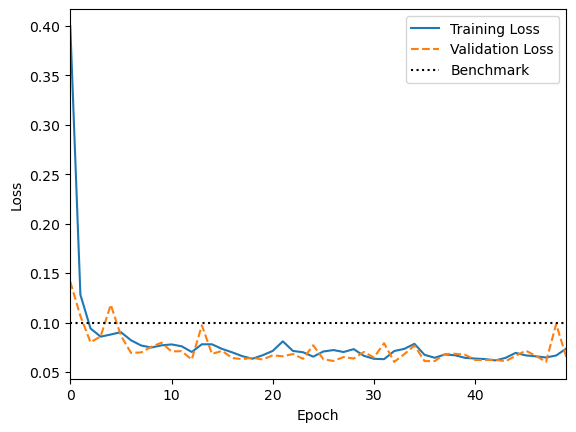

variance of returns for old data:  0.005567340859964665
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[ 2.3756e+02,  1.8031e+06,  2.5021e+11,  4.0965e-02, -1.9933e-03,
         -2.1405e-03, -7.6915e-05,  2.4130e+02,  2.4001e+02,  4.8616e+01,
          1.6351e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(223.0063)
windows last2 price:  tensor(223.8647)
windows last3 price:  tensor(224.2462)
period from idx:  0  to idx  20
prediction at 20:  tensor(229.1983)
last price from test data:  223.0062561035156
real price 20 steps forward:  tensor(237.6956)
kelly weight:  {tensor(0.3721)}
 
lw mean tensor([[ 2.3157e+02,  2.0741e+06,  2.4390e+11,  3.9179e-02, -6.5662e-04,
         -7.9463e-04, -2.6625e-05,  2.3397e+02,  2.3402e+02,  4.6956e+01,
          1.6614e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(237.6956)
windows last2 price:  tensor(23

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)



Mean absolute percentage error (MAPE): 4.17%

First-batch sample comparisons (n = 20):
  Sample  1: Last input price =  252.1481, True =  246.6561, Pred =  247.0470, Pct diff =   0.16%
  Sample  2: Last input price =  238.1774, True =  240.4898, Pred =  245.5602, Pct diff =   2.11%
  Sample  3: Last input price =  246.2708, True =  245.0182, Pred =  244.5549, Pct diff =   0.19%
  Sample  4: Last input price =  247.1379, True =  238.0810, Pred =  248.4833, Pct diff =   4.37%
  Sample  5: Last input price =  248.1014, True =  238.5628, Pred =  247.0021, Pct diff =   3.54%
  Sample  6: Last input price =  245.2109, True =  230.5657, Pred =  248.5849, Pct diff =   7.82%
  Sample  7: Last input price =  239.3335, True =  232.7818, Pred =  246.1643, Pct diff =   5.75%
  Sample  8: Last input price =  242.9949, True =  237.8883, Pred =  245.8357, Pct diff =   3.34%
  Sample  9: Last input price =  237.0212, True =  236.7321, Pred =  241.1058, Pct diff =   1.85%
  Sample 10: Last input price 

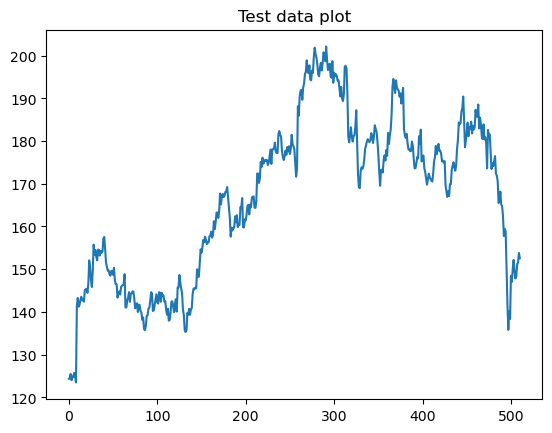

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 3.57618880e+00  3.04256470e+07  1.18267779e+10  6.47422180e-03
 -4.30106086e-02 -4.39629729e-02 -2.78460220e-04  3.98403440e+00
  3.95145295e+00  2.49887626e+01  2.47445707e-02]
[3.20792813e+01 3.97212786e+07 1.06089068e+11 3.44186188e-02
 5.86523034e-04 3.56506250e-04 5.14583852e-05 3.18743206e+01
 3.18727033e+01 5.30458094e+01 1.97374088e-02]
[3.46817477e+01 6.00212472e+07 1.14695658e+11 1.97664671e-02
 2.14212303e-02 2.14607224e-02 7.56455948e-04 3.44160923e+01
 3.44009693e+01 1.12441742e+01 8.89400008e-03]
[-0.82184706 -0.15487235 -0.82184706 -1.41372745 -2.03523005 -2.06514386
 -0.43613723 -0.81038504 -0.81164138 -2.49525188  0.562982  ]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 1.9579257294206078
Normalized Benchmark: 0.1


INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

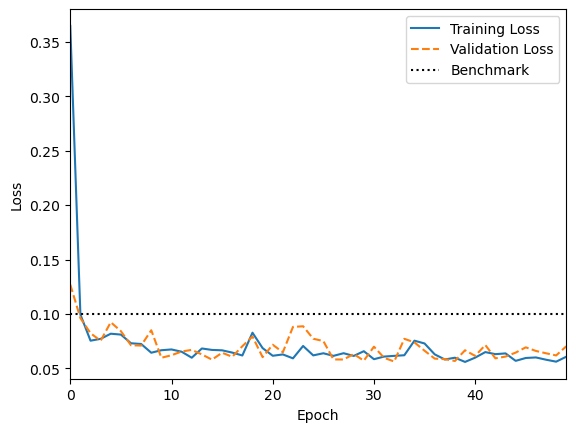

variance of returns for old data:  0.0064163458026785586
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[1.2008e+02, 4.3933e+06, 3.9710e+11, 6.4995e-02, 4.5394e-04, 2.7603e-04,
         3.8430e-05, 1.2005e+02, 1.2033e+02, 4.8094e+01, 1.8685e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(122.3797)
windows last2 price:  tensor(122.7636)
windows last3 price:  tensor(123.3396)
period from idx:  0  to idx  20
prediction at 20:  tensor(122.6053)
last price from test data:  122.37970733642578
real price 20 steps forward:  tensor(145.3996)
kelly weight:  {tensor(0.0230)}
 
lw mean tensor([[1.2819e+02, 5.0445e+06, 4.2394e+11, 6.7956e-02, 4.7130e-03, 4.3174e-03,
         3.4867e-04, 1.2317e+02, 1.2404e+02, 5.8949e+01, 2.4807e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(145.3996)
windows last2 price:  tensor(145.3029)
windows last3 price:  tensor(1

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


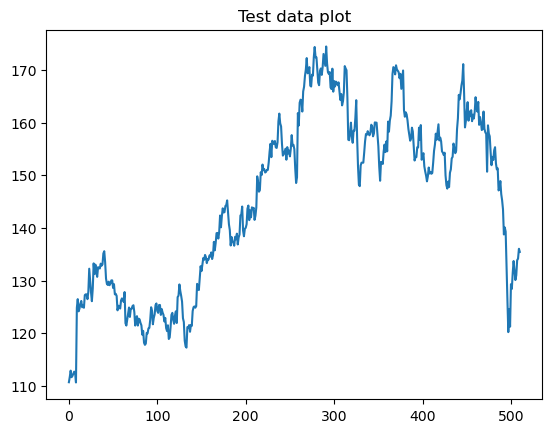

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 2.76596975e+00  8.51722400e+06  4.31734687e+09  2.36340459e-03
 -5.89518352e-02 -6.07609561e-02 -1.39327038e-04  3.11219729e+00
  3.08784515e+00  2.64108343e+01  2.97870997e-02]
[2.77326197e+01 6.27226225e+06 4.32872915e+10 1.39132619e-02
 5.10280511e-04 2.60306392e-04 2.00492032e-05 2.75504724e+01
 2.75488163e+01 5.29843603e+01 2.05678219e-02]
[3.02143619e+01 5.43137118e+06 4.71609933e+10 8.24934883e-03
 2.23469850e-02 2.23667742e-02 3.18279157e-04 2.99754195e+01
 2.99621226e+01 1.08196514e+01 9.20077171e-03]
[-0.8263173   0.41333241 -0.8263173  -1.40009322 -2.6608563  -2.72821024
 -0.50074357 -0.81527717 -0.81639647 -2.45604272  1.00201135]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 1.685724525883231
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

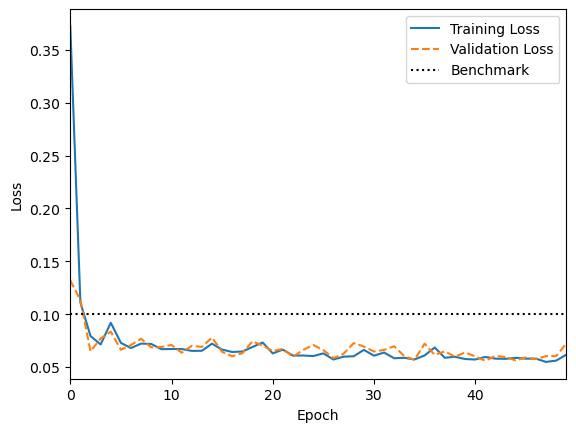

variance of returns for old data:  0.006637611828357787
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[1.0689e+02, 1.9126e+06, 1.6684e+11, 2.7308e-02, 8.9612e-04, 7.0796e-04,
         2.8692e-05, 1.0637e+02, 1.0667e+02, 4.9524e+01, 1.9438e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(109.0790)
windows last2 price:  tensor(110.4156)
windows last3 price:  tensor(111.2272)
period from idx:  0  to idx  20
prediction at 20:  tensor(111.3505)
last price from test data:  109.07901763916016
real price 20 steps forward:  tensor(127.3847)
kelly weight:  {tensor(0.2556)}
 
lw mean tensor([[1.1414e+02, 2.1094e+06, 1.7815e+11, 2.8560e-02, 4.2879e-03, 3.9352e-03,
         1.3238e-04, 1.0998e+02, 1.1062e+02, 5.8636e+01, 2.4116e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(127.3847)
windows last2 price:  tensor(127.3847)
windows last3 price:  tensor(12

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


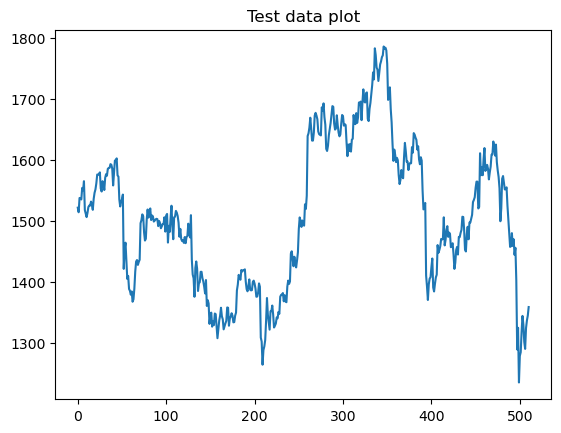

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 2.70022095e+02  1.27078000e+06  4.18588269e+11  2.29143839e-01
 -6.10652330e-03 -6.12524436e-03 -1.39927219e-03  2.79458354e+02
  2.78083609e+02  3.75416964e+01  1.74502300e-02]
[ 4.71184396e+02  1.05752743e+06  7.30430081e+11  3.13926072e-01
  1.26808171e-04 -2.04446214e-05  1.20775905e-05  4.69339401e+02
  4.69352027e+02  5.17071530e+01  1.47510470e-02]
[2.74421903e+02 9.28910785e+05 4.25408852e+11 7.11077367e-02
 1.70850010e-02 1.72055261e-02 6.13833517e-03 2.71289991e+02
 2.71150742e+02 1.22767769e+01 6.62112409e-03]
[-0.73304025  0.22957271 -0.73304025 -1.19230674 -0.36484232 -0.35481622
 -0.22992387 -0.6999191  -0.70539515 -1.15384165  0.40766236]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 23.861516549498827
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

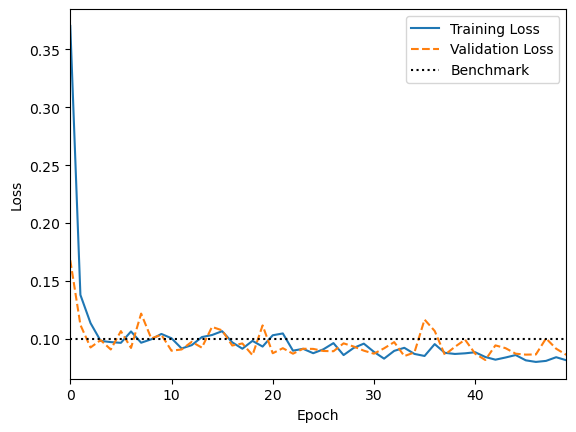

variance of returns for old data:  0.004312255286227896
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[1.4109e+03, 3.0750e+05, 2.1872e+12, 3.5793e-01, 1.3645e-03, 1.3076e-03,
         5.3735e-04, 1.3906e+03, 1.3973e+03, 5.4677e+01, 1.1685e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(1528.6642)
windows last2 price:  tensor(1518.1973)
windows last3 price:  tensor(1506.7335)
period from idx:  0  to idx  20
prediction at 20:  tensor(1506.6697)
last price from test data:  1528.6641845703125
real price 20 steps forward:  tensor(1551.5917)
kelly weight:  {tensor(-0.2191)}
 
lw mean tensor([[1.4816e+03, 2.8092e+05, 2.2968e+12, 3.6835e-01, 3.5125e-03, 3.4607e-03,
         1.3046e-03, 1.4463e+03, 1.4494e+03, 6.3157e+01, 1.0051e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(1551.5917)
windows last2 price:  tensor(1546.1091)
windows last3 price:  t

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


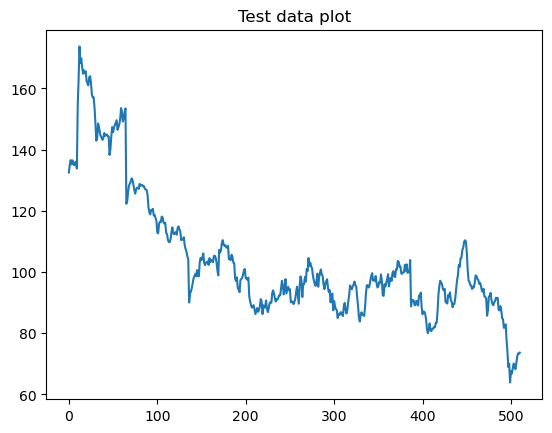

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 2.73251572e+01  1.65003200e+06  7.16752513e+09  3.92365086e-03
 -5.06330515e-02 -5.19598865e-02 -1.98666416e-04  3.01378270e+01
  2.98728204e+01  2.75933695e+01  2.55974566e-02]
[8.34968842e+01 2.59945798e+06 2.19016495e+10 8.83582951e-03
 6.71996112e-04 4.46456769e-04 6.67391163e-06 8.32996535e+01
 8.33025782e+01 5.13740152e+01 2.05527586e-02]
[5.23494822e+01 1.78499709e+06 1.37315305e+10 2.63615470e-03
 2.13175016e-02 2.11952851e-02 1.86248389e-04 5.22331699e+01
 5.21811133e+01 1.18837439e+01 9.14185743e-03]
[-1.07301399 -0.53189217 -1.07301399 -1.86338785 -2.40671015 -2.47254722
 -1.10250794 -1.01777906 -1.02392905 -2.00110722  0.55182418]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 5.456540341359411
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

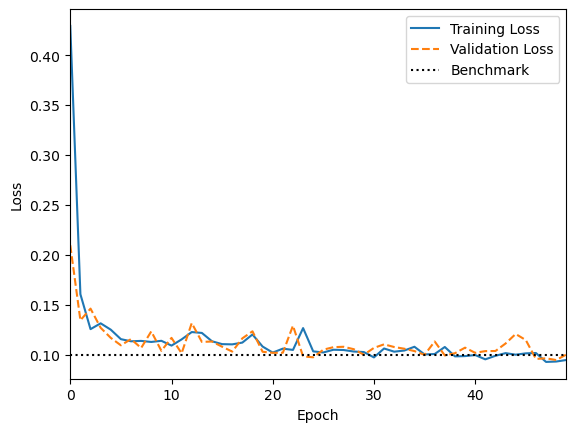

variance of returns for old data:  0.008489762367896116
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[1.2439e+02, 1.7319e+06, 3.2629e+10, 5.3385e-03, 2.0076e-04, 7.0577e-05,
         1.2485e-06, 1.2722e+02, 1.2777e+02, 3.7882e+01, 1.7885e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(127.7000)
windows last2 price:  tensor(126.3000)
windows last3 price:  tensor(127.1500)
period from idx:  0  to idx  20
prediction at 20:  tensor(122.4013)
last price from test data:  127.6999969482422
real price 20 steps forward:  tensor(162.5000)
kelly weight:  {tensor(-0.4503)}
 
lw mean tensor([[1.3673e+02, 2.0453e+06, 3.5866e+10, 5.7408e-03, 6.7254e-03, 6.2317e-03,
         4.2376e-05, 1.2897e+02, 1.3068e+02, 5.6818e+01, 2.3634e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(162.5000)
windows last2 price:  tensor(165.6000)
windows last3 price:  tensor(16

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


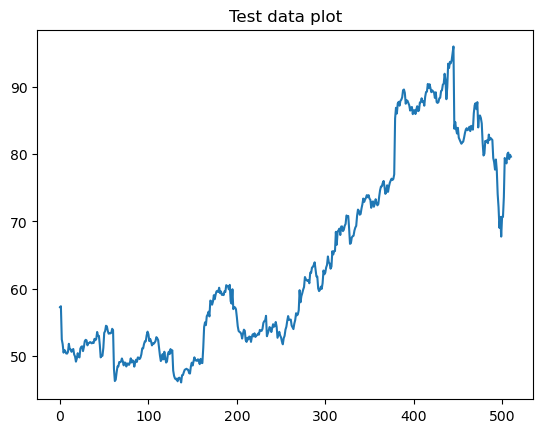

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 3.12475800e+02  5.59376930e+07  9.59588162e+11  5.25298322e-01
 -9.53905175e-03 -9.58483992e-03 -5.01084788e-03  2.81729825e+02
  2.87650963e+02  6.76608207e+01  3.46125789e-02]
[ 7.29566672e+01  1.65471850e+07  2.24044084e+11  1.12123167e-01
 -8.24389246e-04 -1.25074006e-03 -1.34774874e-05  7.33210499e+01
  7.33219249e+01  5.03310007e+01  2.36470188e-02]
[6.25690770e+01 1.50943824e+07 1.92144626e+11 9.87595449e-02
 2.87145654e-02 2.94488121e-02 4.91958186e-03 6.26698315e+01
 6.25673485e+01 1.21334096e+01 1.41271560e-02]
[ 3.82807521  2.60961376  3.82807521  4.18364783 -0.30349275 -0.28300292
 -1.01581202  3.32550399  3.42557329  1.42827289  0.77620436]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 6.057792215129882
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

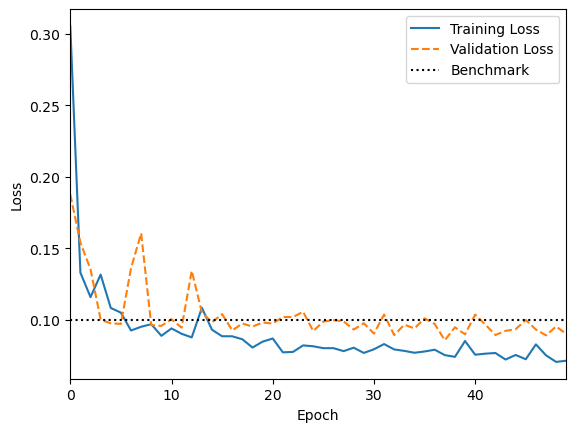

variance of returns for old data:  0.014983579397876468
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[5.3115e+01, 8.8778e+06, 1.6311e+11, 2.6686e-02, 1.2657e-03, 1.1363e-03,
         3.7131e-05, 5.3072e+01, 5.3229e+01, 4.7075e+01, 1.4802e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(56.3482)
windows last2 price:  tensor(56.0999)
windows last3 price:  tensor(56.7160)
period from idx:  0  to idx  20
prediction at 20:  tensor(54.8446)
last price from test data:  56.34817123413086
real price 20 steps forward:  tensor(50.4357)
kelly weight:  {tensor(-0.2180)}
 
lw mean tensor([[ 5.2077e+01,  1.0540e+07,  1.5992e+11,  2.5680e-02, -9.6237e-04,
         -1.1743e-03, -1.7421e-05,  5.2772e+01,  5.2655e+01,  4.5860e+01,
          2.0550e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(50.4357)
windows last2 price:  tensor(49.6449)
windows last3 pric

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


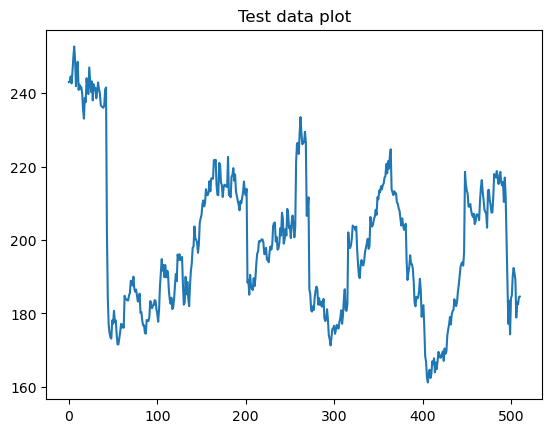

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 9.10091019e+00  2.01714500e+06  2.31301453e+09  1.26619179e-03
 -9.99990767e-03 -1.00502426e-02 -1.26618009e-05  9.08712144e+00
  9.10202532e+00  5.18001043e+01  1.60951852e-02]
[9.26630410e+01 1.05770866e+06 2.35504972e+10 9.40542765e-03
 7.48964901e-04 5.37987006e-04 7.28677146e-06 9.22930987e+01
 9.22945497e+01 5.27025009e+01 1.84358849e-02]
[7.11698507e+01 9.18112535e+05 1.80879599e+10 3.68516664e-03
 2.05024606e-02 2.05583754e-02 1.91914473e-04 7.07585435e+01
 7.07036060e+01 1.19792458e+01 7.77982990e-03]
[-1.17412261  1.04500952 -1.17412261 -2.20864798 -0.52427232 -0.51503241
 -0.10394512 -1.17591422 -1.17663764 -0.07533    -0.30086772]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 6.325181413483725
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

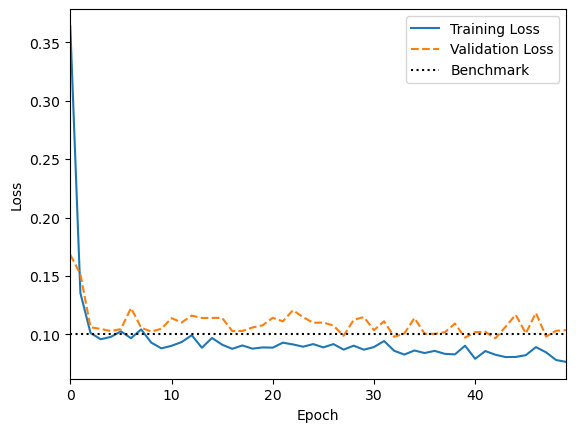

variance of returns for old data:  0.006905603196186679
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[2.2102e+02, 7.6663e+05, 5.6172e+10, 9.1930e-03, 2.2294e-03, 2.0799e-03,
         2.3263e-05, 2.1897e+02, 2.1919e+02, 5.3387e+01, 2.0454e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(243.8951)
windows last2 price:  tensor(242.1080)
windows last3 price:  tensor(243.2367)
period from idx:  0  to idx  20
prediction at 20:  tensor(248.4400)
last price from test data:  243.89505004882807
real price 20 steps forward:  tensor(244.0717)
kelly weight:  {tensor(0.2242)}
 
lw mean tensor([[2.3665e+02, 7.9916e+05, 6.0145e+10, 9.6461e-03, 3.3907e-03, 3.2772e-03,
         3.3436e-05, 2.2927e+02, 2.3011e+02, 6.0958e+01, 1.5357e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(244.0717)
windows last2 price:  tensor(237.5682)
windows last3 price:  tensor(23

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


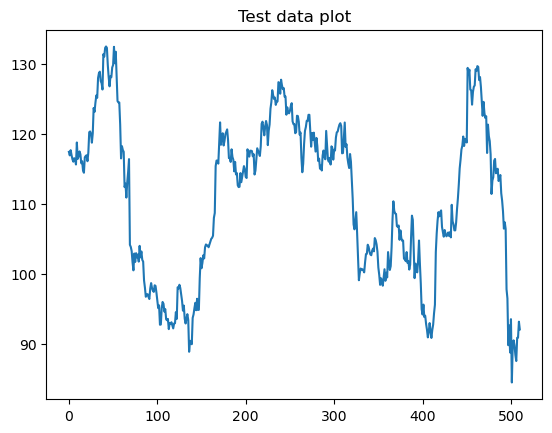

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 1.14148211e+00  9.72000000e+05  2.93832326e+09  1.60849867e-03
 -8.00099289e-03 -8.03317259e-03 -1.28695864e-05  1.18267759e+00
  1.18423892e+00  3.25515117e+01  1.63444294e-02]
[ 3.29634456e+01  5.16560419e+06  8.48521916e+10  2.65025967e-02
 -3.10940224e-04 -5.61950696e-04  7.68471703e-06  3.27882729e+01
  3.27869828e+01  5.37030562e+01  2.00704349e-02]
[3.66231296e+01 6.75806132e+06 9.42726937e+10 1.80291577e-02
 2.23331651e-02 2.24403237e-02 6.18642833e-04 3.64467041e+01
 3.64324587e+01 1.21173060e+01 1.00047737e-02]
[-0.86890344 -0.62053361 -0.86890344 -1.38076877 -0.34433331 -0.33293735
 -0.03322483 -0.86717293 -0.86743374 -1.74556494 -0.37242276]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 2.106951815857292
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

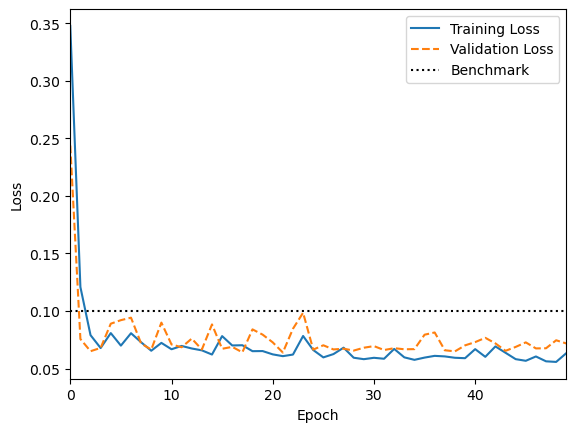

variance of returns for old data:  0.008853323710775235
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[ 1.1549e+02,  4.0647e+06,  2.9728e+11,  4.8654e-02, -4.0114e-04,
         -4.7722e-04, -1.7354e-05,  1.1654e+02,  1.1636e+02,  4.6608e+01,
          1.3117e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(116.3312)
windows last2 price:  tensor(116.4807)
windows last3 price:  tensor(117.7760)
period from idx:  0  to idx  20
prediction at 20:  tensor(114.8319)
last price from test data:  116.33123016357422
real price 20 steps forward:  tensor(116.9492)
kelly weight:  {tensor(-0.1370)}
 
lw mean tensor([[1.1560e+02, 4.4479e+06, 2.9757e+11, 4.7767e-02, 5.6191e-04, 4.8295e-04,
         3.0093e-05, 1.1547e+02, 1.1561e+02, 4.9497e+01, 1.2376e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(116.9492)
windows last2 price:  tensor(116.8494)
windows la

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


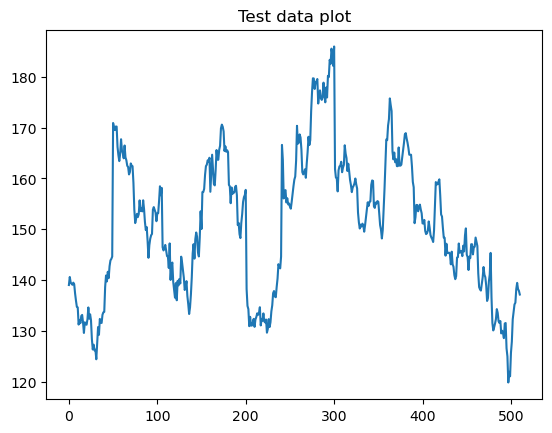

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 5.56863670e+01  9.39295200e+06  7.85227884e+10  4.29849915e-02
 -5.26313638e-02 -5.40669941e-02 -2.26235872e-03  6.30287111e+01
  6.31253374e+01  3.22534727e+01  3.88828957e-02]
[1.09026599e+02 4.47016801e+06 1.53737315e+11 7.01545571e-02
 3.59472535e-04 1.64202285e-04 2.34488674e-05 1.08964146e+02
 1.08963600e+02 5.12521875e+01 1.77715722e-02]
[5.21725108e+01 2.99570683e+06 7.35679349e+10 2.80636786e-02
 1.98506949e-02 1.97227569e-02 1.30405267e-03 5.21180856e+01
 5.20578243e+01 1.17584244e+01 9.21921805e-03]
[-1.02238192  1.64327962 -1.02238192 -0.96813985 -2.66947008 -2.74967626
 -1.75284913 -0.88137226 -0.8805259  -1.61575345  2.2899256 ]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 6.209826816300544
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

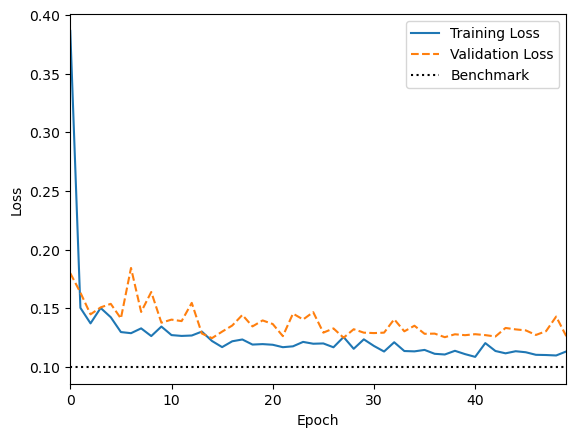

variance of returns for old data:  0.0064114845991847785
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[1.1933e+02, 3.7638e+06, 1.6827e+11, 2.7519e-02, 4.8881e-03, 4.3865e-03,
         1.5010e-04, 1.1714e+02, 1.1720e+02, 5.3731e+01, 2.5998e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(136.7445)
windows last2 price:  tensor(135.0379)
windows last3 price:  tensor(136.4571)
period from idx:  0  to idx  20
prediction at 20:  tensor(133.8937)
last price from test data:  136.74452209472656
real price 20 steps forward:  tensor(131.2137)
kelly weight:  {tensor(-0.2604)}
 
lw mean tensor([[1.2794e+02, 3.6647e+06, 1.8040e+11, 2.8894e-02, 2.1591e-03, 1.6850e-03,
         7.1881e-05, 1.2506e+02, 1.2496e+02, 5.6298e+01, 2.9064e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(131.2137)
windows last2 price:  tensor(131.3607)
windows last3 price:  tensor(

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


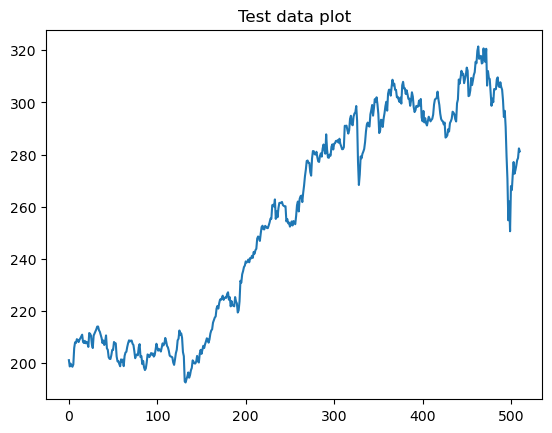

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 1.42888927e+01  4.22727600e+06  2.59524865e+10  1.42069256e-02
 -3.51560694e-02 -3.57889207e-02 -4.99459662e-04  1.45781390e+01
  1.45444687e+01  4.68376428e+01  2.29861783e-02]
[5.08854194e+01 6.12410651e+06 9.24216582e+10 3.15595791e-02
 3.97498058e-04 2.57913752e-04 2.03965845e-05 5.05974564e+01
 5.05981643e+01 5.34938154e+01 1.49451315e-02]
[4.97837632e+01 3.97945072e+06 9.04207532e+10 1.32749882e-02
 1.66832613e-02 1.67189383e-02 5.41994669e-04 4.93979386e+01
 4.93872246e+01 1.18909845e+01 7.08688239e-03]
[-0.73510969 -0.47665637 -0.73510969 -1.30716903 -2.13109216 -2.15604806
 -0.9591538  -0.72916641 -0.73002069 -0.55976632  1.1346381 ]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 2.6211858494989966
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

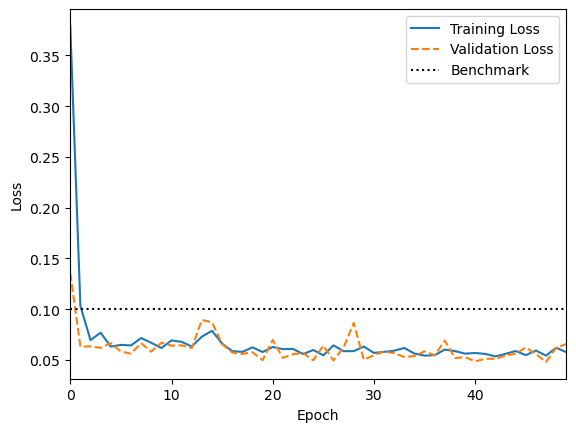

variance of returns for old data:  0.00450694041508163
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[1.9244e+02, 2.8213e+06, 3.4951e+11, 5.7198e-02, 9.3740e-04, 8.4999e-04,
         5.6715e-05, 1.9222e+02, 1.9215e+02, 5.1089e+01, 1.3843e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(200.4973)
windows last2 price:  tensor(200.2121)
windows last3 price:  tensor(200.9727)
period from idx:  0  to idx  20
prediction at 20:  tensor(196.7111)
last price from test data:  200.497314453125
real price 20 steps forward:  tensor(208.1855)
kelly weight:  {tensor(-0.2813)}
 
lw mean tensor([[1.9921e+02, 3.0108e+06, 3.6182e+11, 5.8030e-02, 2.1044e-03, 2.0226e-03,
         1.2351e-04, 1.9567e+02, 1.9615e+02, 5.9195e+01, 1.2982e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(208.1855)
windows last2 price:  tensor(207.6546)
windows last3 price:  tensor(208.

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


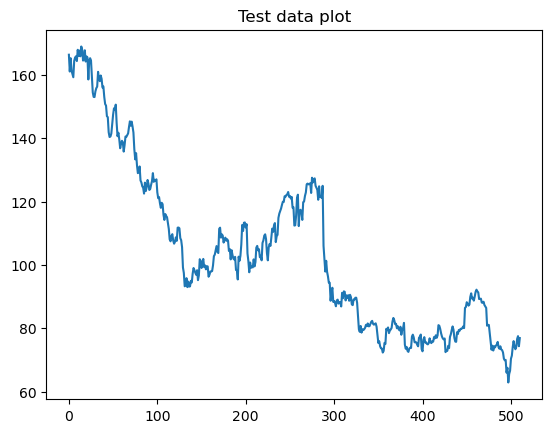

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 2.43462448e+01  2.27230000e+04  5.92142043e+09  3.24150749e-03
 -4.50000037e-02 -4.60439424e-02 -1.45867849e-04  2.38618716e+01
  2.42698545e+01  5.09900698e+01  4.06852812e-02]
[ 7.74961545e+01  1.04483102e+06  1.88483816e+10  6.51122517e-03
  1.74775914e-04 -1.04596044e-04  3.75133368e-06  7.72585792e+01
  7.72607191e+01  5.26148370e+01  2.02412775e-02]
[7.42043833e+01 8.41146542e+05 1.80477669e+10 3.12186232e-03
 2.35973229e-02 2.36715725e-02 1.53079092e-04 7.38992478e+01
 7.38437402e+01 1.31420102e+01 1.09425978e-02]
[-0.71626375 -1.21513669 -0.71626375 -1.04736127 -1.91440274 -1.94069686
 -0.9773979  -0.72256091 -0.71760808 -0.12363156  1.86829527]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 5.93159023780083
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

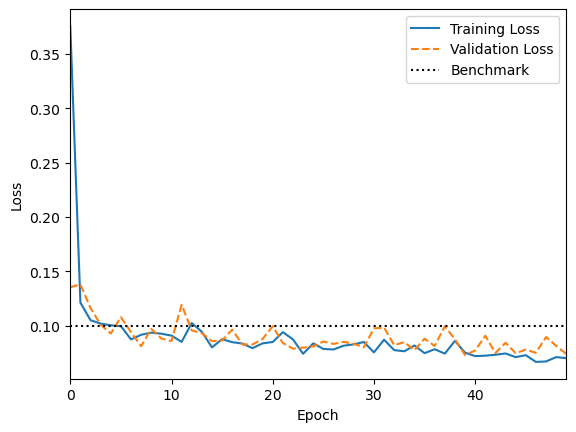

variance of returns for old data:  0.012043251940359061
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[1.5312e+02, 1.0239e+06, 3.7241e+10, 6.0910e-03, 6.9935e-04, 4.1788e-04,
         5.5510e-06, 1.5645e+02, 1.5593e+02, 4.6501e+01, 3.1740e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(165.9000)
windows last2 price:  tensor(163.7500)
windows last3 price:  tensor(162.5500)
period from idx:  0  to idx  20
prediction at 20:  tensor(152.6340)
last price from test data:  165.89999389648438
real price 20 steps forward:  tensor(165.7500)
kelly weight:  {tensor(-0.7287)}
 
lw mean tensor([[1.5754e+02, 8.2662e+05, 3.8318e+10, 6.1417e-03, 3.0913e-03, 2.8900e-03,
         1.9723e-05, 1.5512e+02, 1.5581e+02, 5.3009e+01, 2.2679e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(165.7500)
windows last2 price:  tensor(164.1500)
windows last3 price:  tensor(1

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


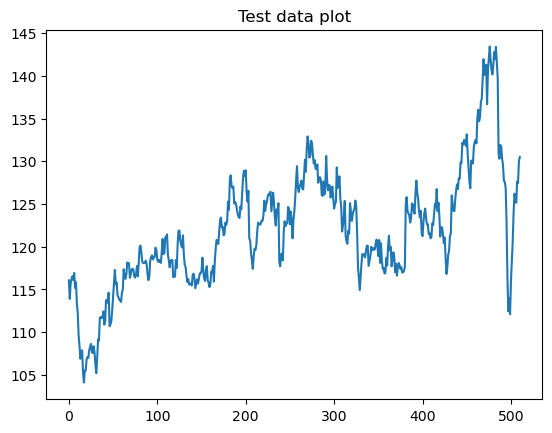

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 2.91987610e+01  5.18249200e+06  1.01166118e+11  5.53804164e-02
 -4.06524032e-03 -4.07352587e-03 -2.25134701e-04  2.88382475e+01
  2.90680731e+01  5.10001816e+01  2.12955097e-02]
[6.40349545e+01 9.72693059e+06 2.21864474e+11 1.03160181e-01
 4.42399820e-04 2.27534337e-04 5.37776015e-05 6.38948581e+01
 6.38963923e+01 5.19973672e+01 1.78057880e-02]
[2.27260966e+01 6.65787940e+06 7.87400180e+10 2.80416554e-02
 2.07380414e-02 2.07282933e-02 2.24236728e-03 2.25792141e+01
 2.25488429e+01 1.13198040e+01 9.64144878e-03]
[-1.53287184 -0.68256547 -1.53287184 -1.70388529 -0.21736094 -0.20749707
 -0.12438297 -1.55260544 -1.54457235 -0.08809212  0.36194993]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 3.4751606250385234
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

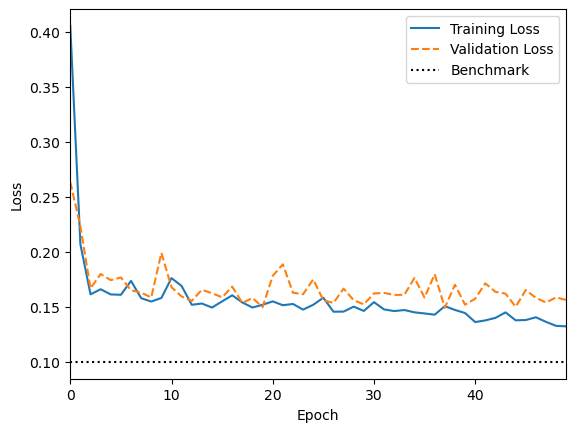

variance of returns for old data:  0.006200695823776553
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[ 1.1891e+02,  6.7411e+06,  4.1200e+11,  6.7410e-02, -1.8307e-03,
         -2.1433e-03, -1.1816e-04,  1.2160e+02,  1.2071e+02,  5.2184e+01,
          1.9945e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(112.8511)
windows last2 price:  tensor(111.9241)
windows last3 price:  tensor(112.9299)
period from idx:  0  to idx  20
prediction at 20:  tensor(109.1910)
last price from test data:  112.8510513305664
real price 20 steps forward:  tensor(106.7963)
kelly weight:  {tensor(-0.4119)}
 
lw mean tensor([[ 1.1060e+02,  6.7457e+06,  3.8320e+11,  6.1531e-02, -3.7457e-03,
         -4.0363e-03, -2.3164e-04,  1.1531e+02,  1.1473e+02,  4.0491e+01,
          2.3807e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(106.7963)
windows last2 price:  tensor(1

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


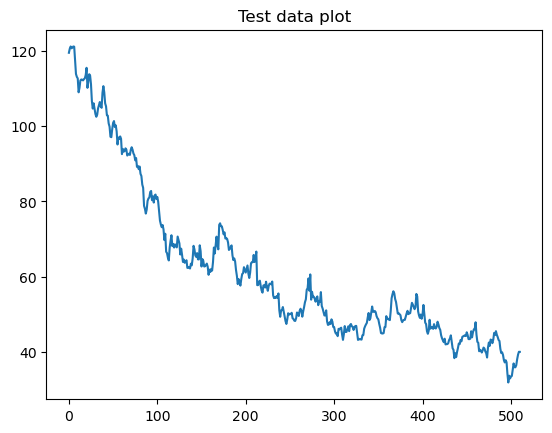

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 2.87091583e-01  1.26169500e+06  5.11867076e+08  2.80206579e-04
 -9.09040599e-03 -9.13197585e-03 -2.54719156e-06  2.96441962e-01
  2.94675045e-01  3.32485079e+01  1.35629413e-02]
[1.69753262e+01 2.26822779e+06 3.02659886e+10 8.20575964e-03
 1.58824632e-03 1.36884383e-03 2.04627442e-05 1.67835329e+01
 1.67850178e+01 5.47798170e+01 1.85749173e-02]
[2.72182118e+01 3.39975914e+06 4.85284395e+10 8.43108740e-03
 2.09987115e-02 2.08552684e-02 2.75583353e-04 2.68755302e+01
 2.68558586e+01 1.22591191e+01 8.35795563e-03]
[-0.61312752 -0.29606003 -0.61312752 -0.94003925 -0.50853845 -0.50350921
 -0.08349538 -0.61346105 -0.61403148 -1.75635043 -0.5996653 ]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 1.539418014641642
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

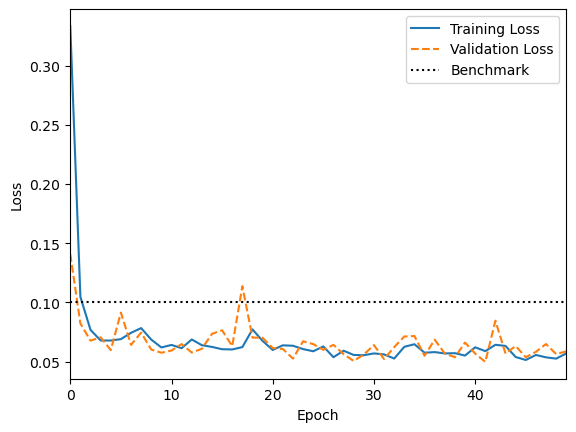

variance of returns for old data:  0.007741348571781633
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[1.1127e+02, 3.2730e+06, 1.9839e+11, 3.2457e-02, 1.2992e-03, 9.1655e-04,
         5.2675e-05, 1.1119e+02, 1.1087e+02, 5.1340e+01, 2.9183e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(117.4972)
windows last2 price:  tensor(114.7922)
windows last3 price:  tensor(113.9561)
period from idx:  0  to idx  20
prediction at 20:  tensor(112.0293)
last price from test data:  117.49720764160156
real price 20 steps forward:  tensor(115.4315)
kelly weight:  {tensor(-0.5289)}
 
lw mean tensor([[1.1268e+02, 3.0942e+06, 2.0090e+11, 3.2229e-02, 1.0741e-03, 8.6237e-04,
         4.0397e-05, 1.1207e+02, 1.1207e+02, 5.1659e+01, 2.2281e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(115.4315)
windows last2 price:  tensor(113.5134)
windows last3 price:  tensor(1

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


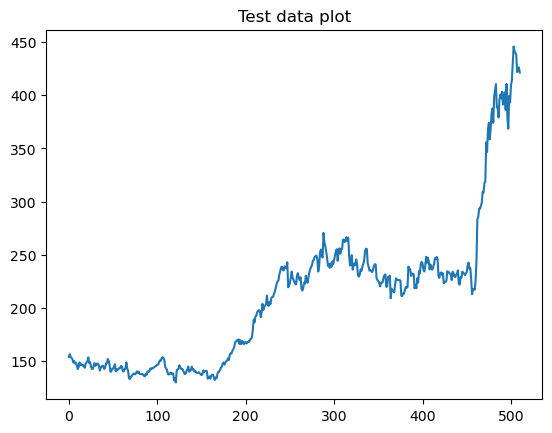

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 8.85961723e+00  5.97897000e+05  4.66473023e+09  2.55356939e-03
 -1.44929227e-02 -1.45989710e-02 -3.70086839e-05  9.26677098e+00
  9.23806656e+00  2.49055810e+01  1.22769308e-02]
[ 3.74283455e+01  9.06409538e+05  1.97066228e+10  7.94761000e-03
 -5.73013375e-04 -7.79302927e-04 -4.44345679e-06  3.72960408e+01
  3.72969864e+01  5.21743547e+01  1.79908963e-02]
[2.55276646e+01 9.26362382e+05 1.34407239e+10 2.54820419e-03
 2.01948054e-02 2.03585062e-02 1.51950738e-04 2.53799264e+01
 2.53551775e+01 1.24179450e+01 9.10416623e-03]
[-1.11912816 -0.33303656 -1.11912816 -2.11680077 -0.68928168 -0.67881543
 -0.21431437 -1.10438735 -1.10663473 -2.19591677 -0.62762096]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)


INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

train loader length:  30
val loader length:  8
Benchmark Celsius: 2.6055753457379933
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

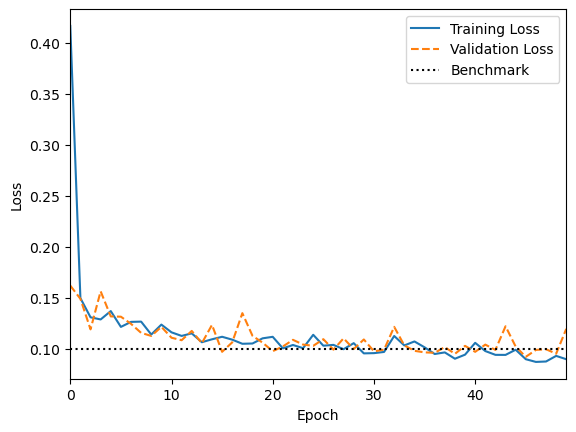

variance of returns for old data:  0.00907406172577072
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[1.4868e+02, 2.1701e+06, 7.8284e+10, 1.2818e-02, 6.1869e-03, 6.0199e-03,
         7.6526e-05, 1.3796e+02, 1.3819e+02, 7.5475e+01, 2.4623e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(159.7236)
windows last2 price:  tensor(160.3179)
windows last3 price:  tensor(158.3368)
period from idx:  0  to idx  20
prediction at 20:  tensor(160.6740)
last price from test data:  159.7235870361328
real price 20 steps forward:  tensor(148.8277)
kelly weight:  {tensor(0.0625)}
 
lw mean tensor([[1.5060e+02, 1.7131e+06, 7.9295e+10, 1.2735e-02, 1.4585e-04, 1.6679e-05,
         3.8763e-06, 1.5123e+02, 1.4944e+02, 5.5716e+01, 1.7566e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(148.8277)
windows last2 price:  tensor(147.5896)
windows last3 price:  tensor(143.

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


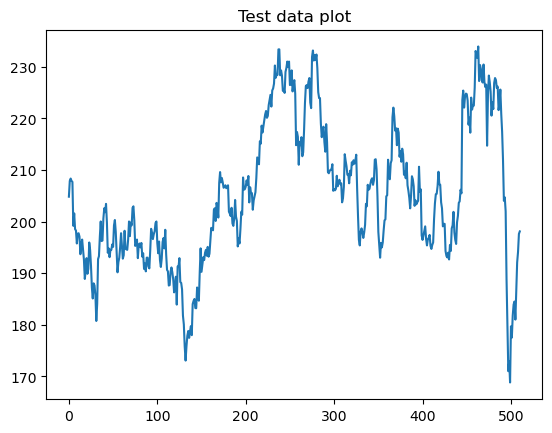

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 2.09454212e+01  6.67306000e+06  2.62737273e+10  1.43827794e-02
 -3.44828405e-02 -3.50914046e-02 -4.95959087e-04  2.33105825e+01
  2.28798623e+01  2.62368658e+01  2.62327041e-02]
[7.32778440e+01 1.22852090e+07 9.19189959e+10 3.68981211e-02
 9.01872080e-04 6.82840206e-04 3.45657355e-05 7.30148614e+01
 7.30159884e+01 5.20932197e+01 1.90827803e-02]
[4.92889478e+01 1.47670805e+07 6.18275640e+10 1.06529580e-02
 2.09187284e-02 2.09190407e-02 8.26796228e-04 4.90033737e+01
 4.89702754e+01 1.12117465e+01 8.37341347e-03]
[-1.06174762 -0.38004459 -1.06174762 -2.11352956 -1.69153267 -1.71012836
 -0.64166333 -1.0143032  -1.02380731 -2.30618431  0.85388399]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 4.575755893555415
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

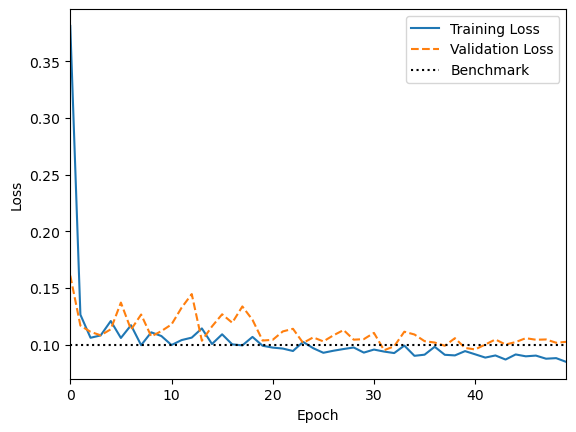

variance of returns for old data:  0.0064650744251737785
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[1.9740e+02, 2.1794e+06, 2.4762e+11, 4.0516e-02, 7.1806e-04, 5.3938e-04,
         3.4157e-05, 1.9837e+02, 1.9779e+02, 5.0576e+01, 1.8078e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(203.8165)
windows last2 price:  tensor(204.1867)
windows last3 price:  tensor(199.9290)
period from idx:  0  to idx  20
prediction at 20:  tensor(196.6808)
last price from test data:  203.81646728515625
real price 20 steps forward:  tensor(192.9198)
kelly weight:  {tensor(-0.4354)}
 
lw mean tensor([[ 1.9645e+02,  2.3815e+06,  2.4643e+11,  3.9550e-02, -2.4805e-04,
         -4.0756e-04, -3.6423e-06,  1.9766e+02,  1.9736e+02,  4.8647e+01,
          1.8924e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(192.9198)
windows last2 price:  tensor(190.4549)
windows l

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


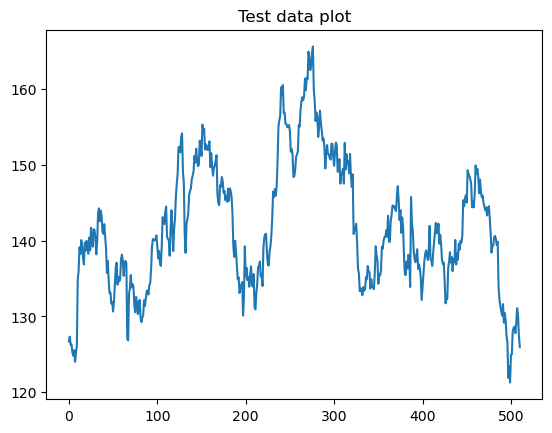

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 5.52285314e-01  3.10878280e+07  3.53173186e+08  1.93334275e-04
 -1.11606881e-02 -1.12234359e-02 -2.15774354e-06  6.08324277e-01
  5.96864715e-01  2.75111428e+01  2.82628697e-02]
[3.32928770e+01 1.61354709e+07 2.12899947e+10 5.85108366e-03
 7.44067850e-04 5.74659160e-04 8.23683655e-06 3.30492712e+01
 3.30511261e+01 5.41173657e+01 1.66435424e-02]
[4.54536321e+01 1.83480127e+07 2.90665054e+10 5.87255350e-03
 1.86607385e-02 1.82785864e-02 1.46737091e-04 4.51913946e+01
 4.51773810e+01 1.24410283e+01 9.03014764e-03]
[-0.72030749  0.81493061 -0.72030749 -0.96342237 -0.63795738 -0.64545992
 -0.07083812 -0.71785673 -0.71837412 -2.13858713  1.28672617]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 2.1108777081025383
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

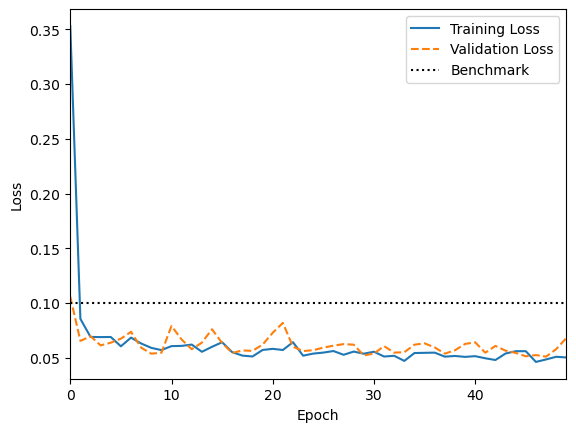

variance of returns for old data:  0.006655515824670857
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[ 1.3307e+02,  1.7754e+06,  8.5096e+10,  1.3927e-02, -2.8082e-03,
         -2.9215e-03, -3.8317e-05,  1.3606e+02,  1.3546e+02,  4.4185e+01,
          1.7721e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(127.5759)
windows last2 price:  tensor(127.6239)
windows last3 price:  tensor(130.2647)
period from idx:  0  to idx  20
prediction at 20:  tensor(129.4930)
last price from test data:  127.57587432861328
real price 20 steps forward:  tensor(139.9638)
kelly weight:  {tensor(0.1842)}
 
lw mean tensor([[1.3062e+02, 1.8868e+06, 8.3528e+10, 1.3409e-02, 1.8773e-03, 1.7368e-03,
         2.6282e-05, 1.3065e+02, 1.3104e+02, 4.7226e+01, 1.5829e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(139.9638)
windows last2 price:  tensor(138.7153)
windows las

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


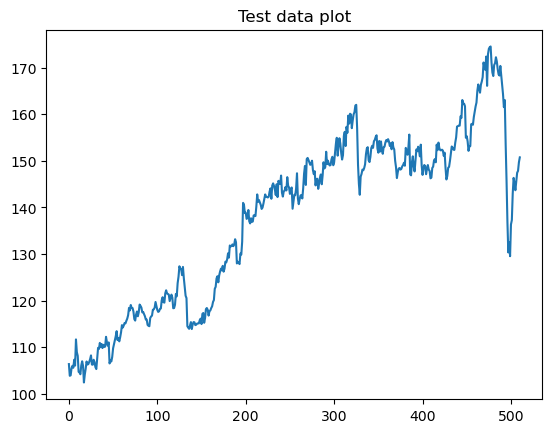

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 1.40866518e+01  2.74833100e+06  2.75132026e+10  1.50612937e-02
 -2.50000215e-02 -2.53178300e-02 -3.76532666e-04  1.50934836e+01
  1.50184601e+01  2.43184247e+01  1.42116058e-02]
[4.35925287e+01 6.41646708e+06 8.51423101e+10 3.59737596e-02
 5.99911375e-04 3.51052607e-04 2.39861118e-05 4.34368840e+01
 4.34382531e+01 5.27633513e+01 1.89445500e-02]
[2.41275239e+01 4.37244804e+06 4.71244312e+10 9.06722261e-03
 2.23148306e-02 2.23087323e-02 7.49049421e-04 2.39482388e+01
 2.39345538e+01 1.13216926e+01 1.25626339e-02]
[-1.22291359 -0.83892045 -1.22291359 -2.30638055 -1.1472161  -1.1506204
 -0.53470274 -1.18352755 -1.18739598 -2.51242703 -0.37674776]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 2.419131320039607
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

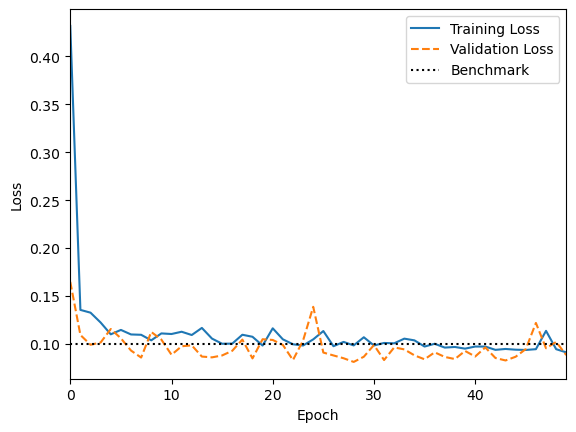

variance of returns for old data:  0.007443521961098039
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[ 1.0525e+02,  4.9816e+06,  2.0556e+11,  3.3629e-02, -1.5779e-03,
         -1.7551e-03, -5.2399e-05,  1.0741e+02,  1.0704e+02,  4.6457e+01,
          1.7275e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(101.7616)
windows last2 price:  tensor(101.3438)
windows last3 price:  tensor(101.6223)
period from idx:  0  to idx  20
prediction at 20:  tensor(98.1493)
last price from test data:  101.76160430908205
real price 20 steps forward:  tensor(106.9611)
kelly weight:  {tensor(-0.4114)}
 
lw mean tensor([[ 1.0235e+02,  5.5913e+06,  1.9990e+11,  3.2066e-02, -4.6810e-04,
         -6.7647e-04, -1.2774e-05,  1.0375e+02,  1.0372e+02,  4.5867e+01,
          2.1073e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(106.9611)
windows last2 price:  tensor(1

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


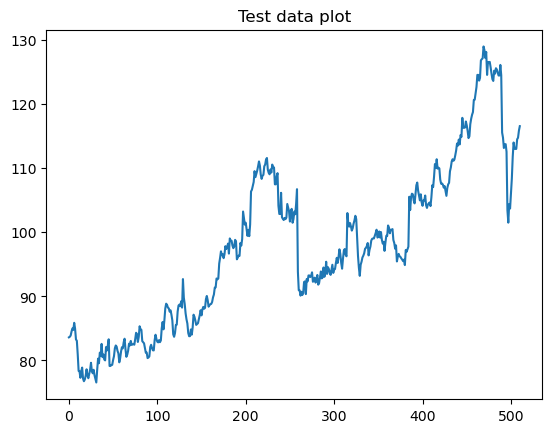

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 1.21157541e+01  4.13292800e+06  2.35624767e+10  1.28985850e-02
 -4.83058221e-03 -4.84228719e-03 -6.23076752e-05  1.24951056e+01
  1.23746467e+01  4.12187009e+01  2.13615980e-02]
[ 4.51649711e+01  5.74300774e+06  8.78359339e+10  3.72580912e-02
  8.87767732e-06 -1.44123749e-04  1.55836970e-06  4.50530711e+01
  4.50531593e+01  5.19501185e+01  1.53713672e-02]
[2.37902621e+01 3.97591911e+06 4.62668268e+10 9.43756005e-03
 1.74698174e-02 1.75076002e-02 6.40534090e-04 2.37351724e+01
 2.37227778e+01 1.09854963e+01 8.35623180e-03]
[-1.38919095 -0.40495787 -1.38919095 -2.58112331 -0.27701834 -0.26834994
 -0.09970749 -1.37171809 -1.37751628 -0.97687145  0.7168579 ]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 2.1515384663039625
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

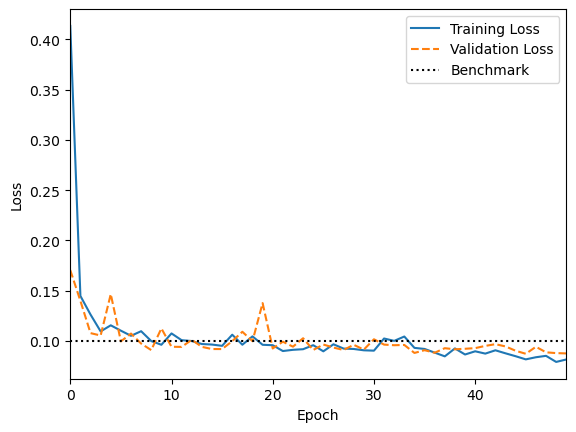

variance of returns for old data:  0.004298513790745119
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[ 8.5368e+01,  7.3274e+06,  1.6602e+11,  2.7164e-02, -2.2579e-03,
         -2.4299e-03, -6.0469e-05,  8.7911e+01,  8.7533e+01,  4.2263e+01,
          2.0908e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(80.8749)
windows last2 price:  tensor(80.8035)
windows last3 price:  tensor(81.2143)
period from idx:  0  to idx  20
prediction at 20:  tensor(79.0720)
last price from test data:  80.87493133544922
real price 20 steps forward:  tensor(78.6244)
kelly weight:  {tensor(-0.3400)}
 
lw mean tensor([[ 8.0377e+01,  7.0550e+06,  1.5632e+11,  2.5097e-02, -2.9932e-03,
         -3.1615e-03, -7.5825e-05,  8.3130e+01,  8.2931e+01,  3.9901e+01,
          1.8522e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(78.6244)
windows last2 price:  tensor(77.6421

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


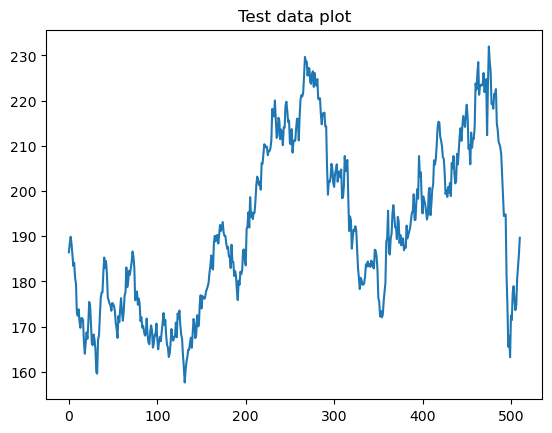

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 2.17024612e+01  6.15515200e+06  9.25436352e+09  5.06602918e-03
 -1.22249355e-02 -1.23002746e-02 -6.19318798e-05  2.35423344e+01
  2.31997035e+01  3.48655619e+01  2.78043304e-02]
[8.87106067e+01 4.95111541e+06 3.78279769e+10 1.59784979e-02
 4.50949434e-04 2.38509220e-04 9.74852610e-06 8.85095323e+01
 8.85083001e+01 5.18358309e+01 1.90412280e-02]
[4.86472367e+01 5.58465793e+06 2.07441547e+10 5.24759168e-03
 2.06261118e-02 2.06071518e-02 3.46192654e-04 4.85460904e+01
 4.84962994e+01 1.12936794e+01 7.69865524e-03]
[-1.37742963  0.2155972  -1.37742963 -2.0795194  -0.61455523 -0.60846758
 -0.20705352 -1.33825808 -1.34667175 -1.50263422  1.13826405]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 5.369761980646684
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

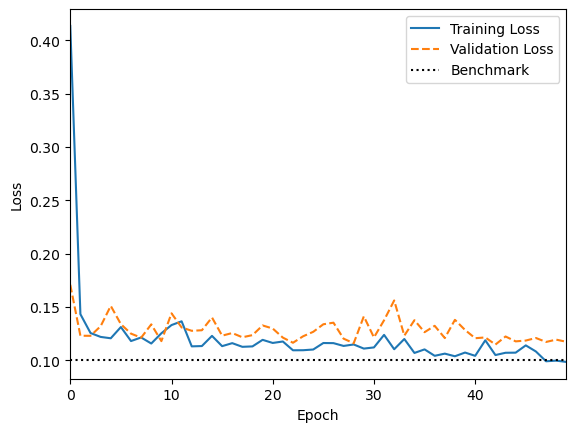

variance of returns for old data:  0.006312502464334213
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[1.8102e+02, 1.5846e+06, 7.7191e+10, 1.2634e-02, 6.9004e-04, 4.6426e-04,
         1.0703e-05, 1.8029e+02, 1.7952e+02, 5.3997e+01, 2.4533e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(182.4845)
windows last2 price:  tensor(184.3917)
windows last3 price:  tensor(180.9029)
period from idx:  0  to idx  20
prediction at 20:  tensor(183.0262)
last price from test data:  182.4844970703125
real price 20 steps forward:  tensor(168.7156)
kelly weight:  {tensor(0.0374)}
 
lw mean tensor([[ 1.7776e+02,  1.5211e+06,  7.5800e+10,  1.2173e-02, -2.2303e-03,
         -2.4309e-03, -2.4536e-05,  1.8092e+02,  1.8004e+02,  4.6791e+01,
          2.0988e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(168.7156)
windows last2 price:  tensor(166.2502)
windows last

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


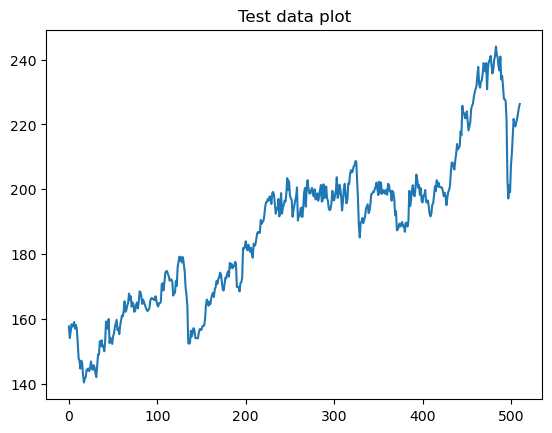

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 2.53812160e+01  1.73165900e+06  2.85297571e+10  1.56177766e-02
 -3.68850819e-02 -3.75825408e-02 -5.76062968e-04  2.71038941e+01
  2.68580950e+01  2.58662916e+01  1.72791768e-02]
[7.03080354e+01 3.76293194e+06 7.90297506e+10 3.32683804e-02
 3.95726952e-04 1.81848130e-04 1.57045429e-05 7.01016028e+01
 7.01038864e+01 5.27801146e+01 1.77878104e-02]
[3.87469289e+01 3.62729674e+06 4.35534873e+10 9.41777855e-03
 2.06488432e-02 2.07050261e-02 5.64197476e-04 3.85745113e+01
 3.85517744e+01 1.16038558e+01 1.19815954e-02]
[-1.15949368 -0.55999635 -1.15949368 -1.87417911 -1.80546719 -1.82392375
 -1.04886593 -1.11466632 -1.12175878 -2.3193862  -0.04245124]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 3.8143632948175505
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

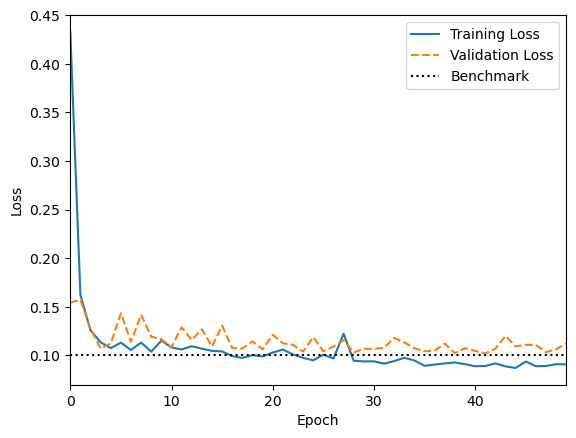

variance of returns for old data:  0.009202894375464678
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[ 1.5734e+02,  4.1846e+06,  1.7686e+11,  2.8930e-02, -1.3959e-03,
         -1.6166e-03, -4.0731e-05,  1.6133e+02,  1.6000e+02,  4.9092e+01,
          1.9225e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(154.3654)
windows last2 price:  tensor(151.4568)
windows last3 price:  tensor(152.3551)
period from idx:  0  to idx  20
prediction at 20:  tensor(145.4645)
last price from test data:  154.36537170410156
real price 20 steps forward:  tensor(144.3567)
kelly weight:  {tensor(-0.6011)}
 
lw mean tensor([[ 1.4801e+02,  3.9832e+06,  1.6638e+11,  2.6700e-02, -2.6002e-03,
         -2.7797e-03, -7.0328e-05,  1.5332e+02,  1.5271e+02,  4.2065e+01,
          1.9862e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(144.3567)
windows last2 price:  tensor(

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


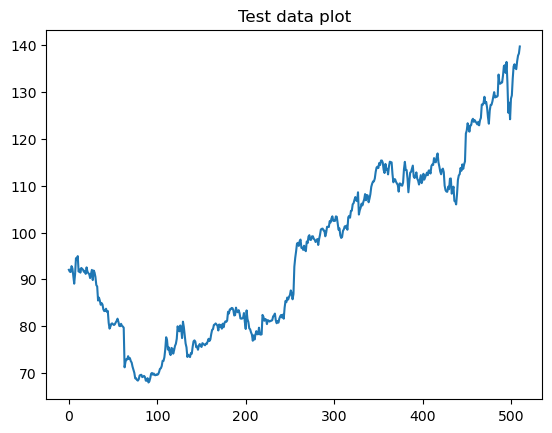

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 4.89801369e+01  1.16962100e+06  3.34324716e+10  1.83016234e-02
 -5.16667485e-02 -5.30493074e-02 -9.45585376e-04  4.81021118e+01
  4.92007052e+01  4.97850548e+01  3.30417673e-02]
[4.90080342e+01 2.53045543e+06 3.34515135e+10 1.49376812e-02
 6.04517877e-04 3.77474590e-04 1.16759211e-05 4.89379288e+01
 4.89392713e+01 5.15572828e+01 1.86206250e-02]
[2.24655013e+01 1.69886981e+06 1.53343228e+10 3.99082080e-03
 2.10820884e-02 2.14321978e-02 3.25101167e-04 2.23710741e+01
 2.23415354e+01 1.21388437e+01 9.82286620e-03]
[-1.24178622e-03 -8.01023378e-01 -1.24178622e-03  8.42919902e-01
 -2.47941596e+00 -2.49282796e+00 -2.94450280e+00 -3.73615040e-02
  1.17016973e-02 -1.45996436e-01  1.46811959e+00]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 2.8807548965552745
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

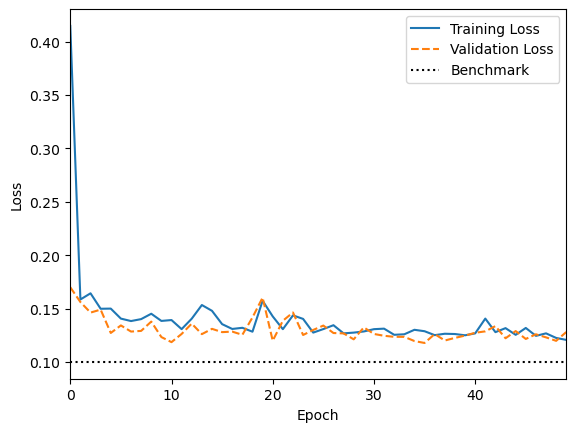

variance of returns for old data:  0.007919504858639842
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[8.5817e+01, 2.5779e+06, 5.8576e+10, 9.5897e-03, 3.1527e-03, 3.0779e-03,
         3.1075e-05, 8.3700e+01, 8.3874e+01, 6.0224e+01, 1.3770e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(92.1649)
windows last2 price:  tensor(91.6855)
windows last3 price:  tensor(91.8163)
period from idx:  0  to idx  20
prediction at 20:  tensor(91.2224)
last price from test data:  92.16488647460938
real price 20 steps forward:  tensor(92.5571)
kelly weight:  {tensor(-0.1149)}
 
lw mean tensor([[9.0156e+01, 2.6131e+06, 6.1538e+10, 9.8741e-03, 2.2275e-03, 2.1262e-03,
         2.3046e-05, 8.8362e+01, 8.8325e+01, 6.0490e+01, 1.3461e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(92.5571)
windows last2 price:  tensor(91.1626)
windows last3 price:  tensor(91.8163)


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


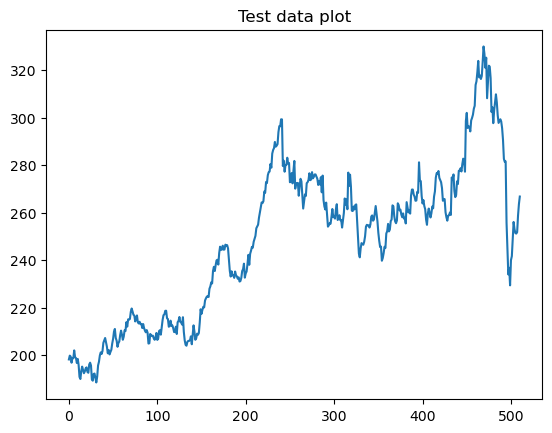

INFO: 
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | SimpleLSTM       | 296 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
296 K     Trainable params
0         Non-trainable params
296 K     Total params
1.185     Total estimated model params size (MB)
7         Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollec

in sequences shape:  (1168, 40, 11)
targets shape:  (1168, 1)
[ 1.63902645e+01  2.72569000e+07  2.60359347e+10  1.42526068e-02
 -9.34555413e-03 -9.38949782e-03 -1.33198508e-04  1.70300261e+01
  1.69249449e+01  3.33200238e+01  1.43622256e-02]
[6.48121952e+01 1.25297287e+07 1.02954170e+11 4.03038420e-02
 4.50602707e-04 2.31007183e-04 2.62016673e-05 6.45396128e+01
 6.45394300e+01 5.22707136e+01 1.87561780e-02]
[4.62541977e+01 1.46998211e+07 7.34747916e+10 1.26411713e-02
 2.09231091e-02 2.09748192e-02 8.92310091e-04 4.59345647e+01
 4.59041237e+01 1.20923915e+01 8.41347271e-03]
[-1.04686565  1.00186058 -1.04686565 -2.06082448 -0.46819795 -0.45866927
 -0.17863765 -1.03428838 -1.03725943 -1.56715814 -0.52225193]
in sequences norm shape:  (1168, 40, 11)
targets norm shape:  (1168, 1)
train loader length:  30
val loader length:  8
Benchmark Celsius: 4.193464299455392
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

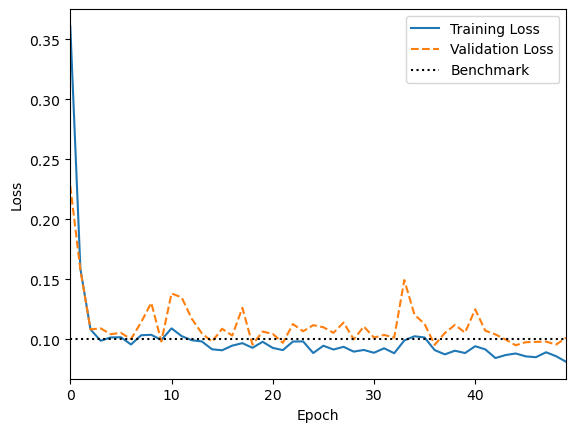

variance of returns for old data:  0.007686944472055873
start window shape:  torch.Size([40, 11])
test data shape torch.Size([511, 11])
lw mean tensor([[1.8868e+02, 3.9686e+06, 2.9971e+11, 4.9048e-02, 1.6772e-03, 1.3730e-03,
         9.1706e-05, 1.8863e+02, 1.8821e+02, 5.2567e+01, 1.7482e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(197.5815)
windows last2 price:  tensor(196.4049)
windows last3 price:  tensor(182.9535)
period from idx:  0  to idx  20
prediction at 20:  tensor(186.2811)
last price from test data:  197.5815277099609
real price 20 steps forward:  tensor(194.8517)
kelly weight:  {tensor(-0.6523)}
 
lw mean tensor([[1.9105e+02, 4.4213e+06, 3.0348e+11, 4.8687e-02, 1.0785e-03, 7.9621e-04,
         6.2240e-05, 1.9074e+02, 1.9054e+02, 5.0988e+01, 2.3891e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 40, 11])
windows last price:  tensor(194.8517)
windows last2 price:  tensor(194.4752)
windows last3 price:  tensor(19

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_460216\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


In [7]:
from data.data_preprocessing import retrive_and_extract_relevant_data_values, generate_loaders_and_benchmark
from single_asset_models.CrossAttentionGRUV1 import CrossAttentionGRUV1
from single_asset_models.CrossAttentionLSTMV1 import CrossAttentionLSTMV1
from single_asset_models.SimpleGRU import SimpleGRU
from single_asset_models.SimpleLSTM import SimpleLSTM
from train.train_functions import plot_training, test_model_output
from model_inference.inference_functions import test_model_output_percentage_diff
import deeplay as dl

from model_inference.inference_functions import generate_weights_from_predictions
tickers = ['VOLV-B.ST', 'KINV-B.ST', 'TEL2-B.ST', 'SCA-B.ST', 'SWED-A.ST']
all_weights = []
tickers = all_tickers
MAPE = []
#tickers = ['TEL2-B.ST']
epochs = 50
for ticker in tickers:
    data_values, dataframe = retrive_and_extract_relevant_data_values(df=df, feature_cols=feature_cols, chosen_ticker=ticker, no_plotting=True)
    n_features = data_values.shape[1]
    train_loader, val_loader, benchmark, train_mean, train_std = generate_loaders_and_benchmark_new_norm(raw_numpy_data=data_values, 
                                                                     window_step_length=window_step_length,
                                                                     window_size=window_size,
                                                                     num_test_points=num_test_points,
                                                                     horizon=horizon,
                                                                     target_idx=target_idx,
                                                                     minimal_plotting=False
                                                                     )
    #cross_attn_lstm_v1 = CrossAttentionLSTMV1(in_dim=n_features, hidden_dim=120, num_hidden_layers=3, out_dim=1, dropout=0.1, num_heads=5)
    simple_lstm = SimpleLSTM(input_size=n_features, hidden_size=120, num_hidden_layers=3, output_size=1, dropout=0.1)
    #trained_chosen_model_path = train_model(chosen_model, epochs=epochs, optimizer=, train_loader=train_loader, val_loader=val_loader, benchmark=benchmark)
    #chosen_model = cross_attn_lstm_v1
    chosen_model = simple_lstm
    chosen_model_reg = dl.Regressor(chosen_model, optimizer=dl.Adam(lr=0.001)).create()

    trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
    trainer.fit(chosen_model_reg, train_loader, val_loader)
    train_losses = trainer.history.history["train_loss_epoch"]["value"]
    val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
    plot_training(epochs, train_losses, val_losses, benchmark)
    preds_norm, weights = generate_weights_from_predictions_new_norm(chosen_model_reg, 
                                                  window_size, 
                                                  data_values, 
                                                  target_idx,
                                                  num_of_future_predictions=num_test_points, 
                                                  horizon=horizon,
                                                  kelly_clip=15,
                                                  print_values_for_allocation=True)
    all_weights.append(weights)
    print('\n \n \n TEST \n \n')
    test_loader = generate_test_data_loader(data_values[-num_test_points:])
    mape_ticker = test_model_output_percentage_diff_new_norm(chosen_model_reg, test_loader, train_mean, train_std, target_idx)
    MAPE.append(mape_ticker)

all mean abs percent errors per ticker [4.165623664855957, 5.649200916290283, 5.328375339508057, 6.040502071380615, 9.537117004394531, 6.7296319007873535, 8.813421249389648, 9.128469467163086, 8.342427253723145, 3.716897487640381, 10.412775993347168, 3.8168106079101562, 11.171815872192383, 7.590147495269775, 5.320831298828125, 5.399664878845215, 4.328805923461914, 5.419239521026611, 6.015377998352051, 4.630224227905273, 5.390340328216553, 5.770969390869141]
all mean 6.487212267788974
(22, 500)
(500,)


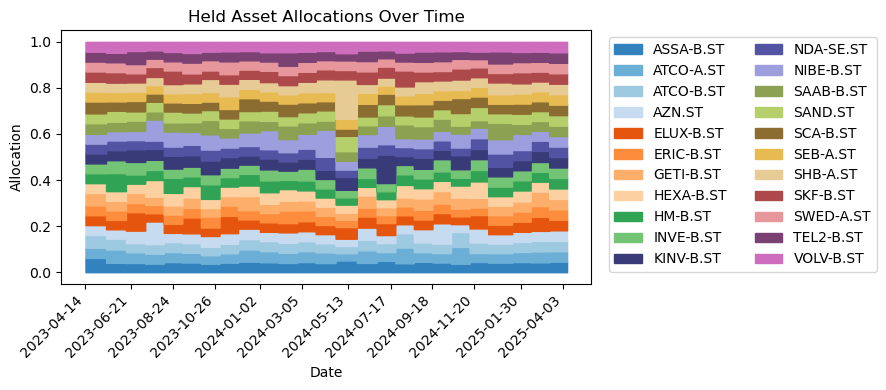

In [8]:
import numpy as np
import matplotlib.pyplot as plt
trading_cost = 0.005
print('all mean abs percent errors per ticker',MAPE)
print('all mean', np.mean(MAPE))

from allocation_functions.allocation_functions import allocate_from_weights, plot_allocations

test_indices = df.index[-(num_test_points)*22::22]
test_indices = test_indices[:int(horizon*np.floor(num_test_points/horizon))]
#print(all_weights.shape)

all_weights = np.array(all_weights)

np.save('saved_weights\\simple_lstm_20horizon_120hidden_new_norm_40ws_5step_17_04_23.npy', all_weights)

alloc = allocate_from_weights(all_weights, horizon=horizon, num_of_test_points=num_test_points)
print(alloc.shape)
alloc_diff = np.diff(alloc, axis=1)
alloc_diff = np.concatenate([alloc_diff, np.zeros((len(tickers),1))], axis=1)
alloc_diff = 0.5* np.sum(np.abs(alloc_diff), axis=0)
print(alloc_diff.shape)

def plot_allocations(alloc, tickers, dates):
    n_assets, total_steps = alloc.shape
    print(total_steps)
    
    

    # Time axis
    t = np.arange(total_steps)

    # Compute cumulative allocations for stacking
    cumsum = np.cumsum(alloc, axis=0)

    plt.figure(figsize=(20,16))
    # Plot filled areas for each asset
    for i in range(n_assets):
        bottom = cumsum[i-1] if i > 0 else np.zeros_like(t)
        top = cumsum[i]
        plt.fill_between(t, bottom, top, step='post', label=tickers[i])
    
    plt.xlabel('Time Step')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend()

    plt.tight_layout()
    plt.show()
#plot_allocations(alloc, tickers, test_indices)

def plot_allocations(alloc, tickers, dates):
    n_assets, T = alloc.shape
    # Stack allocations
    cumsum = np.cumsum(alloc, axis=0)
    base_cmap = plt.get_cmap('tab20c')
    extra_cmap = plt.get_cmap('tab20b')
    colors = []
    for i in range(n_assets):
        if i < 10:
            colors.append(base_cmap(i))  # tab20 has 20 distinct
        else:
            # pick from hsv evenly for any extras
            colors.append(extra_cmap((i-10) / max(1, n_assets-10)))

    #cmap = plt.get_cmap('tab20', n_assets)
    #colors = [cmap(i) for i in range(n_assets)]

    plt.figure(figsize=(9,4))
    for i, ticker in enumerate(tickers):
        bottom = cumsum[i-1] if i>0 else np.zeros(T)
        top    = cumsum[i]
        # use dates on the x-axis
        plt.fill_between(dates, bottom, top, step='post', label=ticker, color=colors[i])

    # now the ticks are the dates themselves
    plt.xticks(
        dates[::45], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )

    plt.xlabel('Date')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend(ncol=2, bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.show()

# call with your alloc, tickers and test_indices as dates:
plot_allocations(alloc, tickers, test_indices)
#np.save('best_allocations.npy',alloc)

500
ret assa 11-12 jul 0.006843340697032293
(500,)
Portfoliot final return:  0.9620573870640807
(500,)
Index final return 1.0344549885288998


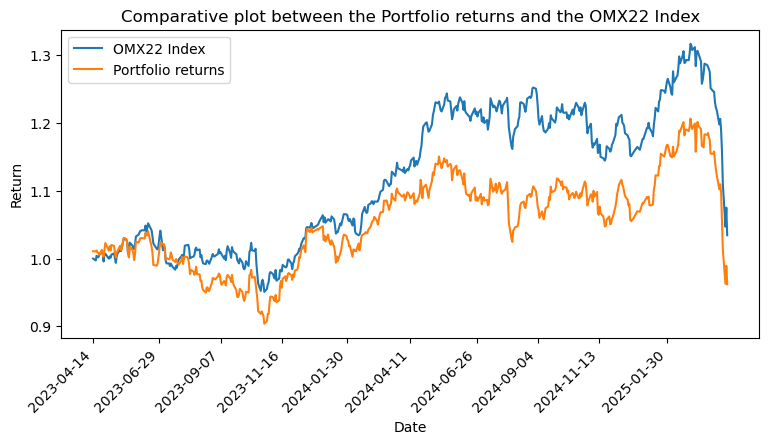

In [9]:
from allocation_functions.allocation_functions import calculate_asset_returns_cont, calculate_portfolio_returns, calculate_cumulative_portfolio_returns
import matplotlib.pyplot as plt

print(len(test_indices))

returns = calculate_asset_returns_cont(df, tickers, num_of_test_points=num_test_points)
print('ret assa 11-12 jul', returns[0,0] )

#print(alloc.shape)
#print(returns)

portfolio_returns = calculate_portfolio_returns(alloc, returns[:,:alloc.shape[1]])
#print(portfolio_returns)

portfolio_returns_with_tradingcost = np.where(portfolio_returns > 0, portfolio_returns - alloc_diff*trading_cost, portfolio_returns)
portfolio_returns_with_tradingcost = portfolio_returns - alloc_diff*trading_cost
print(portfolio_returns_with_tradingcost.shape)
portfolio_cum_return = calculate_cumulative_portfolio_returns(portfolio_returns_with_tradingcost)
print('Portfoliot final return: ',portfolio_cum_return[-1])



df_omx22 = pd.read_csv(
    "data/MCAP_22_Index_raw.csv",
    parse_dates=["Date"],
    index_col="Date"
)


index_test_values = df_omx22['MCAP_22_Index'].iloc[-num_test_points:-11].values

#index_diffs = np.diff(index_test_values, axis=0)
#index_diffs = np.concatenate([index_diffs, np.zeros((1))], axis=0)/index_test_values
index_diffs = index_test_values / index_test_values[0]
print(index_diffs.shape)
#print(index_diffs)
#cum_prod_index = 1 * np.cumprod(1 + index_diffs)
#cum_prod_index = cum_prod_index[:int(horizon*np.floor(num_test_points/horizon))]
cum_prod_index = index_diffs
print('Index final return', cum_prod_index[-1])
plt.figure(figsize=(9,4))
plt.plot(test_indices, cum_prod_index, label='OMX22 Index')
plt.plot(test_indices, portfolio_cum_return, label='Portfolio returns')
plt.title('Comparative plot between the Portfolio returns and the OMX22 Index')
plt.xlabel('Date')
plt.ylabel('Return')
plt.xticks(
        test_indices[::50], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )
plt.legend()



In [ ]:
import torch
cross_attn_lstm_v1.eval()

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        x_batch, y_batch = batch
        #print(y_batch)
        test_prediction = cross_attn_lstm_v1(x_batch)
        attn_weights = cross_attn_lstm_v1.get_attn_weights()
        all_attn = attn_weights
        if i > 5:
            break
        
print(all_attn.shape)
attn = all_attn.detach().cpu().numpy()  
#attn = all_attn[0].detach().cpu().numpy() 
 
import random
#random.seed(42)
indices = random.sample(range(21), 4)
print("Randomly selected samples:", indices)

attn4 = attn[indices]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16,4), sharex=True, sharey=True)

im_mean = attn4.mean(0, keepdims=True)

for i, ax in enumerate(axes):
    im = ax.imshow(
        attn4[i],
        origin="lower",
        cmap="viridis",
        aspect="auto", 
       
    )
    ax.set_title(f"Sample {i}")
    ax.set_xlabel("Key time step")
    if i == 0:
        ax.set_ylabel("Query time step")



plt.tight_layout()
plt.show()

plt.imshow(im_mean)
plt.show()

NameError: name 'cross_attn_lstm_v1' is not defined

: 